In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import time
import pickle
from imports import *

c:\Users\jh102\anaconda3\envs\fivar_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
base_dir = "data"

# 1. [Data]

In [3]:
# Load data # log_price: 분단위 로그가격
log_price_ = pd.read_csv("log price.csv")
log_price_ = log_price_.rename(columns={"Unnamed: 0": "Date"})
log_price_["Date"] = pd.to_datetime(log_price_["Date"])
log_price_ = log_price_.set_index("Date").sort_index()

log_price = log_price_.loc['2016-01-01':'2019-12-31'] # 논문에서 사용한 기간

print(log_price.shape)
print(type(log_price.index), log_price.index.min(), log_price.index.max())
# log_price.head()
# log_price.isna().sum().sum()

(388830, 200)
<class 'pandas.core.indexes.datetimes.DatetimeIndex'> 2016-01-04 09:30:00 2019-12-31 15:59:00


In [ ]:
# print(log_price.loc['2016-01-04'].iloc[-1])
# len(log_price.loc['2016-01-04'])

# 2. [Functions]

## functions : PRVM and Gamma

In [4]:
# Appendix A.2 (p.45~46)

def g_wedge(x: np.ndarray) -> np.ndarray: # weight function g(x)
    return np.minimum(x, 1.0 - x)

def project_to_psd_spectral(A: np.ndarray, eps: float = 1e-10) -> np.ndarray: # PSD 1e-10
    # A_sym = (A + A.T) / 2.0
    # w, V = la.eigh(A_sym); w = np.maximum(w, eps); #
    w, V = la.eigh(A); w = np.maximum(w, eps); # 음수 고유값을 0에 가까운 값으로 #
    return (V * w) @ V.T

def prvm_one_day_exact(log_price_day, alpha_u=0.47, c0=4.0, do_psd_projection=True):
    Y = log_price_day.values.astype(np.float64) # log_price_day에는 daily로 넣어줘야 함 (390,200)
    m, p = Y.shape[0]-1 , Y.shape[1] # m:389(분) , p:200(자산수) 
    K = int(np.floor(np.sqrt(m))) # pre-averaging 구간 길이
    dY = np.diff(Y, axis=0) # (m, p) # Ybar에 들어갈 수익률
    
    # Ybar 계산
    l_vec = np.arange(1, K) # [1,2,...,K-1]
    g_vals = g_wedge(l_vec / K) # g(l/k) 

    L = m - K + 1 # 감마햇 인덱스 k=1...m-K+1
    Ybar = np.zeros((L, p)) #(m-K+1,p)
    for k in range(L): 
        Ybar[k] = np.sum(dY[k:k+K-1] * g_vals[:, None], axis=0) #dY[k:k+K-1]: (k-1,p) 
    
    # Threshold u 계산
    # if L <= K:
    #     raise ValueError(f"L(={L}) <= K(={K}) : 하루 표본 부족") #

    prod = np.abs(Ybar[:L-K]) * np.abs(Ybar[K:]) # T_hat 공식 참고
    scale_T = (m / (m - 2*K + 1)) * (np.pi / (2*K))
    T_hat = scale_T * np.sum(prod, axis=0)
    u = c0 * np.sqrt(T_hat) * ((K / m) ** alpha_u)
    
    # Truncation 구현
    mask = (np.abs(Ybar) <= u).astype(np.float64) # (L,p)
    Ybar_masked = Ybar * mask #truncated 된 Ybar
    
    # Yhat 계산 (1)
    grid = np.arange(0, K + 1) / K
    w_sq = (g_wedge(grid)[1:] - g_wedge(grid)[:-1]) ** 2 # (K,)
    
    # Bias sums
    Bias_trunc_sum = np.zeros((p,p)) # 점프 제거용 (점프 확인용)
    Bias_untrunc_sum = np.zeros((p,p)) # 전체용

    # Yhat 계산 (2), 누적 (마지막 k=L-1이면 k+K=m) (m-K+1,p,p)
    for k in range(L):
        dY_seg = dY[k:k+K]                        # (K,p) K분 동안의 dY
        Yhat_local = (dY_seg.T * w_sq) @ dY_seg   # ((p,K)*(K))@(K,p)=(p,p), p.45 메모 참고

        Bias_untrunc_sum += Yhat_local # (점프 고려X) 공분산을 전체 합계에 더함

        mk = mask[k] #(p,) k번째 mask를 곱해줘서 임계치만큼 tuncation
        Bias_trunc_sum += np.outer(mk, mk) * Yhat_local #(점프 고려) 공분산을 합계에 더함

    # Gamma hat 완성
    Main_untrunc = Ybar.T @ Ybar #(점프 고려X)
    Main_trunc   = Ybar_masked.T @ Ybar_masked #(점프 고려)
    psi = 1.0 / 12.0
    Gamma_untrunc = (1.0 / (psi * K)) * (Main_untrunc - 0.5 * Bias_untrunc_sum) # Jump 계산에 활용
    Gamma_trunc   = (1.0 / (psi * K)) * (Main_trunc   - 0.5 * Bias_trunc_sum) # Algorithm Step으로 넘어갈 것

    JV_hat = Gamma_untrunc - Gamma_trunc # Jump 계산
    
    if do_psd_projection:
        Gamma_untrunc = project_to_psd_spectral(Gamma_untrunc)
        Gamma_trunc   = project_to_psd_spectral(Gamma_trunc)
        JV_hat        = project_to_psd_spectral(JV_hat)

    return Gamma_trunc, Gamma_untrunc, JV_hat

def build_Gamma_list_from_log_price(log_price, do_psd_projection=True):
    Gamma_list = []
    JV_list = []
    days = []
    grouped = log_price.groupby(log_price.index.date) #daily로 u계산 #
    print(f"Generating PRVM matrices and JUMP (JV) for {len(grouped)} days...")

    for d, df_day in tqdm(grouped):
        # df_day = df_day.dropna(axis=0, how="any")
        # df_day = df_day.ffill(axis=0).dropna(axis=0, how="any") #결측치 없음 확인
        # if len(df_day) < 20: continue #
        Gamma_trunc, Gamma_untrunc, JV_hat = prvm_one_day_exact(
            df_day, do_psd_projection=do_psd_projection
        )
        Gamma_list.append(Gamma_trunc)
        JV_list.append(JV_hat)
        days.append(pd.Timestamp(d))
    return Gamma_list, JV_list, days


In [5]:
# target_date = '2017-01-04' ; df_day = log_price.loc[target_date] 

# Gamma_list (997,200,200), JV_list, days는 아래 실행 코드에서 확인
# m (389,)
# K (19,)
# L (371,) m-K+1
# Ybar (371,200) (L,p)
# Ybar[0,:5] : [ 0.00303378  0.00038796  0.00152311  0.00118077 -0.00073947]
# u (200,) (p,)  
# u[:5] : [0.00306524 0.00117887 0.00253421 0.00265025 0.00151576]

## functions : Algorithm steps 1~5

In [5]:
def step1_decompose_input_volatility(Gamma_list_raw, psd_eps=1e-10, do_psd_projection=False): # PRVM 결과 일별 공분산 행렬
    Gamma_hat_list, eigvals_list, eigvecs_list = [], [], []
    for G in Gamma_list_raw: # G:(p,p)
        G_sym = 0.5 * (G + G.T) # 이미 대칭 (필요X)
        # G_use = project_to_psd_spectral(G_sym, eps=psd_eps) if do_psd_projection else G_sym # PRVM에서 PSD를 수행했기에 제외
        w, V = la.eigh(G_sym) # la.eigh는 오름차순 반환
        idx = np.argsort(w)[::-1] # 큰 고유값부터 내림차순 : (p,)
        Gamma_hat_list.append(G_sym)
        eigvals_list.append(w[idx]) # 큰 고유값 순대로 저장
        eigvecs_list.append(V[:, idx]) # 고유값에 맞춰 고유벡터 배열
    return Gamma_hat_list, eigvals_list, eigvecs_list # (p,p), (p,) (p,p) # Gamma_hat_list, eigvals_list, eigvecs_list

def step2_factor_components(Gamma_hat_list, days, r=3, ell=22): # 최근 22일
    n = len(Gamma_hat_list) # 시계열
    p = Gamma_hat_list[0].shape[0] # 자산
    
    start_idx = max(0, n - ell)
    Gamma_bar = np.mean(Gamma_hat_list[start_idx:n], axis=0) #)(p,p) ell일 평균

    w_bar, V_bar = la.eigh(0.5 * (Gamma_bar + Gamma_bar.T)) # 대칭 후 고유값분해 (p,) (p,p), 평균 공분산의 고유값 분해로 QF 구함 
    idx = np.argsort(w_bar)[::-1] # 고유값 내림차순
    QF = V_bar[:, idx[:r]] # 상위 r개 고유값에 대응하는 고유벡터 추출

    xi = np.empty((n, r)) # 고유벡터에 대응하는 고유값 xi, (날짜별 팩터의 공분산 xi)
    for d in range(n): # 모든 날짜에 대해
        xi[d, :] = np.diag(QF.T @ Gamma_hat_list[d] @ QF) / p # 대각원소만 뽑음(r,)
        
    return {"xi": pd.DataFrame(xi, index=days, columns=[f"xi_{i+1}" for i in range(r)]), 
            "QF": QF, "r": r, "p": p} #w_bar, V_bar, QF, xi

def step3_idiosyncratic_input_estimator(Gamma_hat_list, eigvals_list, eigvecs_list, r=3):
    Sigma_bar_list = []
    L_factor_list = [] #
    for d in range(len(Gamma_hat_list)): 
        Gd = Gamma_hat_list[d] #해당 날짜의 Gammahat (p,p)
        w, V = eigvals_list[d], eigvecs_list[d] #고유값 벡터 w:(p,) , 고유벡터 행렬 V:(p,p) (k번째 고유벡터 == V[:,k])
        factor_part = (V[:, :r] * w[:r]) @ V[:, :r].T
        L_factor_list.append(factor_part)
        S = Gd - factor_part
        Sigma_bar_list.append(0.5 * (S + S.T))
    return Sigma_bar_list, L_factor_list # idio 성분, factor 성분 #Sigma_bar_list, L_factor_list

def step4_gics_block_masking(Sigma_bar_list, same_sector):

    Sigma_hat_list = []
    mask = same_sector.astype(np.float64)
    
    for S in Sigma_bar_list:
        # 1. Masking (같은 섹터끼리만 남기고 나머지는 0)
        S_hat = S * mask
        
        diag_val = np.diag(S_hat).copy() 
        np.fill_diagonal(S_hat, diag_val) #대각 성분은 원래 값으로 복원 (threshold대상X)
        S_hat = 0.5 * (S_hat + S_hat.T)
            
        Sigma_hat_list.append(S_hat)
        
    return Sigma_hat_list # Sigma_hat_list


def step5_idio_components(Sigma_hat_list, days, ell=22):
    n = len(Sigma_hat_list)
    p = Sigma_hat_list[0].shape[0]
    start_idx = max(0, n - ell)
    Sigma_bar = np.mean(Sigma_hat_list[start_idx:], axis=0) # (p,p)
    w_bar, V_bar = la.eigh(0.5 * (Sigma_bar + Sigma_bar.T)) #대칭화 후 고유값 분해, QI 추출
    # 내림차순 정렬 (큰 고유값부터)
    idx = np.argsort(w_bar)[::-1]
    QI = V_bar[:, idx] # (p,p) 고유벡터 p개 모두 사용 (r개가 아님), 개별자산의 리스크는 모든 자산에 영향
    
    xi_idio = np.empty((n, p), dtype=np.float64)
    for d in range(n): #계산 과정 메모
        xi_idio[d, :] = np.sum(QI * (Sigma_hat_list[d] @ QI), axis=0) #sum((p,p)*((p,p)@(p,p))) = (p,) -> 더해서 d번째 행에 대입: (n,p)
        
    return {
        "xi_idio": pd.DataFrame(xi_idio, index=days, columns=[f"xi_I{j+1}" for j in range(p)]), 
        "QI": QI, 
        "p": p # Step7에서 필요
    } # QI, xi_idio

## functions : Estimate Beta for Factor (steps 6)

In [6]:
def step6_factor_var(df_xi, p, h=1, c_tau=0.25, c_omega=4.0):

    raw_data = df_xi.values # df에서 index: datetime, value:xi 정보, Step2 결과 (n,r)
    n, r = raw_data.shape # 251, 3
    
    # 팩터별 표준편차 계산 (아래 변수 정의)
    factor_stds = np.std(raw_data, axis=0, ddof=1) # (r,)
    factor_stds[factor_stds < 1e-12] = 1.0 # 분모 0 방지
    data_scaled = raw_data / factor_stds # (n,r)
    
    # page21. 변수 정의 (Eq 4.13) sigma_F
    sigma_F = np.sqrt(np.sum(data_scaled**2) / (n * r))
    scaling_factor = (n / np.log(p))**0.25

    # Lagged matrix 생성 (공통) # Lagged Matrix: [t-1, t-2, ..., t-h] , 1일 전부터 h일 전까지 반복, 학습 대상인 과거 값 (전체 길이 n에서 앞뒤로 h만큼 자르고 조립)
    X_lags = np.hstack([data_scaled[h-lag : n-lag] for lag in range(1,h+1)]) # 타겟 시점 Y보다 lag만큼 앞선 과거 데이터를 잘라 hstack으로 길게 붙임
    regressor_stds = np.tile(factor_stds, h)

    # Input Truncation 제어
    if np.isinf(c_omega):
        X_train = X_lags
        omega_F = np.inf
        omega_vec_real = np.full(r*h, np.inf) # Step8에서 clip 안되게 inf 유지
    else:
        omega_F = c_omega * sigma_F * scaling_factor # p.21 (4.13) # input의 truncation 파라미터
        X_train = np.clip(X_lags, -omega_F, omega_F) # Truncation (intercept 제외) # Scaled Data 기준으로 omega_F 적용 p.10 # (n-h, r*h) 
        omega_vec_real = omega_F * regressor_stds # Step 8에서 사용할 Truncation 임계값도 원래 스케일로 반환 (각 팩터별로 스케일이 다르므로 벡터 형태)

    # LOSS에서의 epsilon 설정 (tau_F)
    if np.isinf(c_tau):
        model_loss = 'squared_error' # ols: Truncation 없는 순수 제곱 오차
        model_epsilon = 0.1
    else:
        model_loss = 'huber' # H-Lasso: huber loss 사용
        model_epsilon = float(c_tau*sigma_F*scaling_factor) # tau_F : # p.21 (4.13) # Humber loss의 truncation 파라미터
    
    # Design Matrix , Y_target = 맞추고 싶은 값
    Y_target = data_scaled[h:] # 0~h-1 번째 과거 데이터 버림 (예측 대상서 제외), (n-h,r)
    
    # SGD Estimation
    beta_hats = []
    iter_counts = [] #반복 횟수 저장용
    
    model = SGDRegressor(
        loss=model_loss,
        epsilon=model_epsilon, #tau_F임   # Huber Loss Threshold (Scaled 기준) # 함수 내부에서 epsilon이 어떻게 처리되는지 확인
        penalty=None,       # Factor Part는 규제 없음
        fit_intercept=True, # 상수항 학습 # 표준화 후 intercept 포함해서 학습하는지 확인
        max_iter=500,      # Factor part의 반복 횟수
        tol=1e-15,
        shuffle=True,       # 매 반복마다 데이터 섞을지 결정
        random_state=42
    )

    for i in range(r): # 팩터 수 만큼 반복
        model.fit(X_train, Y_target[:, i]) # Y_target[:,i]: i 번째 팩터의 타겟 시계열 (n-h,)
        # 계수 저장: [Intercept, Coef_1, ..., Coef_rh] # beta_i:[intercept1개, coef(r*h개)]
        beta_i = np.concatenate(([model.intercept_[0]], model.coef_)) #intercept[0] 배열에서 길이1인 리스트(스칼라)추출
        beta_hats.append(beta_i)
        iter_counts.append(model.n_iter_) #반복 횟수 저장
    
    # Descaling (Original Scale 복원) 
    beta_mat_scaled = np.column_stack(beta_hats) # beta_hats[0], beta_hats[1]... 을 2차원 행렬로 합침 :(r, intercept 1 + coef r*h)
    beta_final = np.zeros_like(beta_mat_scaled)
    
    # A. Intercept 복원
    beta_final[0, :] = beta_mat_scaled[0, :] * factor_stds # Y = alpha+beta*X에서 Y가 2배 되면 alpha도 2배 되도록
    
    # B. Slope 복원
    regressor_stds = np.tile(factor_stds, h) # 설명변수 X들의 std벡터(n*h,) , np.tile:(o)(o)(o) -> (ooo)
    
    for i in range(r):
        # (rh,) * scalar / (rh,)
        beta_final[1:, i] = beta_mat_scaled[1:, i] * (factor_stds[i] / regressor_stds) # beta_mat_scaled[1:,i] # i번째 팩터를 예측하는 기울기 벡터 (r*h,) , factor_stds[i]: 타겟 Y 팩터의 std
    
    return {
        "beta_hat": beta_final,
        "omega_vec": omega_vec_real, # 예측 시 X를 자를 때 사용
        "omega_F": omega_F, # 참고
        "iter_counts": iter_counts 
    } # omega_F, sigma_F, tau_F, x_lags, X_train, Y_target

## functions: OLS (Step7,8)

In [7]:
def step7_idio_ols(df_idio, ols_window=22):
    recent = df_idio.iloc[-ols_window:]
    pred_mean = recent.mean(axis=0).values if len(recent) > 0 else df_idio.iloc[-1].values
    return {"method": "ols_rolling_mean", "pred_mean": pred_mean, "params": None} # Step8에서 사용

def step8_predict_ols(step6_res, step7_res, step2_res, step5_res, h=1):
    # 1. Factor Prediction # Step6에서 구한 베타햇으로 내일의 팩터xi 예측
    last_h_fact = step2_res["xi"].iloc[-h:].values[::-1].flatten() # Step2에서 구한 과거 팩터(xi) 중 최근 h개, 최신순 정렬 후 1차원 벡터로 변환
    X_fact = np.concatenate(([1.0], last_h_fact)) # 절편1 추가 : [1.0, f_t-1, f_t-2 ...]
    
    if "omega_vec" in step6_res: # Step6 결과물 임계값(omega_vec) 으로 입력변수 자르기 (절변은 제외)
        X_fact[1:] = np.clip(X_fact[1:], -step6_res["omega_vec"], step6_res["omega_vec"])
    
    xi_next_F = X_fact @ step6_res["beta_hat"] # 내적(1,1+rh)(1+rh,r) = (r,) 팩터 3개의 내일 예측값 # 수식1 팩터 예측(intercept+coef+lags)
    
    # ols는 단순 평균 ols_rolling_mean 사용
    xi_next_I = step7_res["pred_mean"]
    
    # 3. Reconstruction (공통) 수식2 Gamma_tilda = psi+sigma
    QF, QI = step2_res["QF"], step5_res["QI"] # 팩터 고유벡터와 개별 고유벡터
    G_factor = (QF * xi_next_F) @ QF.T # 수식2 첫 번째 시그마 부분
    G_idio = (QI * xi_next_I) @ QI.T # 수식2 두 번째 시그마 부분
    G_next_raw = (step2_res["p"] * G_factor) + G_idio
    G_next = 0.5 * (G_next_raw + G_next_raw.T) 
    
    return {
        "G_next": G_next,          # 최종 예측 공분산 행렬 (p, p)
        "xi_next_F": xi_next_F,    # 예측된 팩터 (r,)
        "xi_next_I": xi_next_I,    # 예측된 개별자산 변동성 (p,)
        "G_factor": G_factor,      # 시스템적 리스크 행렬 (p, p)
        "G_idio": G_idio           # 고유 리스크 행렬 (p, p)
    }

## functions: LASSO (Step7,8)

In [8]:
def step7_idio_lasso(df_factor, df_idio, h=1, c_eta_grid=np.logspace(-1,1,30) , bic_coef_threshold=1e-10):
    df_all = pd.concat([df_factor, df_idio], axis=1) # [factor(r개)|Idio(p개)] r+p개
    vals_raw = df_all.values.astype(np.float64) #(251, r+p)
    n_obs, r_plus_p = vals_raw.shape #(251), (r+p)
    r,p = df_factor.shape[1], df_idio.shape[1] # r=3, p=200
    
    # Standardization 실행 (전체 데이터 표준화) LASSO 규제를 공정하게 적용하도록 변수 스케일 맞춤
    mean_v = vals_raw.mean(axis=0) # (r+p,)
    std_v = vals_raw.std(axis=0, ddof=1) #(r+p,)
    std_v[std_v < 1e-12] = 1.0 # 분모 0 방지
    vals_sc = (vals_raw - mean_v) / std_v # 예측대상 Idio part으로 사용

    # Build Var(h) design
    n_eff = n_obs - h # h 시점 제외한 학습 가능한 샘플 수
    Y_target_all = vals_sc[h:,r:] # 예측대상 Idio 성분 (팩터 부분은 Step6에서 함) ,(n-h,p)
    # X_input 설명변수로 (t-1,...t-h시점) 팩터+개별 변수 모두 사용  # h-lag 부터 n_obs-lag까지 X_blocks리스트 추가 후 열방향으로 합침 (n-h,(r+p)*h)
    X_input = np.concatenate([vals_sc[h-lag : n_obs-lag, :] for lag in range(1, h+1)], axis=1)

    # 규제 파라미터 그리드 설정 (p.21, Eq 4.14)
    logp = np.log(p) if p>1 else 1.0 # 정수p, 1이면 1로 취급 (log(1)=0이기 때문)
    base_alpha = np.sqrt(logp / n_eff) # base_alph * sorted_grid로 규제가 큰 모델(변수 적음)부터 학슴, 속도향상
    sorted_grid = sorted(c_eta_grid, reverse=True) # 큰 규제부터 작은 규제로 (Warm start 효과)

    # 자산별 Lasso 학습 및 BIC 기반 최적 모델 선택
    beta_I_list = [] # 자산별 베타 저장
    iter_counts = [] # 반복 횟수 저장

    model = Lasso(fit_intercept=True, warm_start=True, max_iter=1500, tol=1e-10, selection="cyclic") # cyclic(순서) vs random(무작위)
    
    for i in range(p):
        y = Y_target_all[:, i] # i번째 자산의 Idio 변동성 (n_eff,)

        # 새로운 타겟에 대해 모델 파라미터 초기화 (Warm start는 alpha loop 내에서만 유효해야 함)
        # warm_start=True일 경우 이전 coef를 유지하려 함. 따라서 i가 바뀔 때마다 coef를 리셋해주는 것이 안전함.
        best_bic, best_coef = np.inf, None
        best_iter = 0 # 자산i의 최적 반복횟수 변수 초기화

        for c_eta in sorted_grid:
            model.set_params(alpha=c_eta * base_alpha)
            model.fit(X_input, y)
            
            full_beta = np.concatenate(([model.intercept_], model.coef_))
            mse = np.mean((y - model.predict(X_input))**2) #MSE에러 생성
            k_params = np.count_nonzero(np.abs(full_beta) > bic_coef_threshold) #1e-10보다 큰(살아남은) 변수가 몇개인가. (낮을수록 좋음)
            bic = n_eff * np.log(mse + 1e-12) + k_params * np.log(n_eff) # BIC 계산

            if bic < best_bic:
                best_bic, best_coef = bic, full_beta.copy()
                best_iter = model.n_iter_
                
        
        # Descaling
        sig_y, mu_y = std_v[r+i], mean_v[r+i]
        mu_x_full, sig_x_full = np.tile(mean_v, h), np.tile(std_v, h) # 입력 변수의 평균 반복((r+p)*h), 입력 변수의 표준편차 반복((r+p)*h)

        real_slope = best_coef[1:] * (sig_y / sig_x_full) # 기울기 복원
        real_intercept = (mu_y + sig_y * best_coef[0]) - np.sum(real_slope * mu_x_full) #절편 복원 # 메모
        beta_I_list.append(np.concatenate(([real_intercept], real_slope))) # 최종 저장
        iter_counts.append(best_iter)
    
    return {
        "method": "lasso",
        "beta_I_list": beta_I_list, # (1+(r+p)h,)
        # 추후 Step 8에서 Truncation을 위해 mean/std 정보 필요할 수 있음
        "std_info": {"mean": mean_v, "std": std_v, "scaling_factor": 1.0},
        "params": {"varpi": np.inf, "tau": None},
        "iter_counts": iter_counts
    }

def step8_predict_lasso(step6_res, step7_res, step2_res, step5_res, h=1):
    # 1. Factor Prediction # Step6에서 구한 베타햇으로 내일의 팩터xi 예측
    last_h_fact = step2_res["xi"].iloc[-h:].values[::-1].flatten() # Step2에서 구한 과거 팩터(xi) 중 최근 h개, 최신순 정렬 후 1차원 벡터로 변환
    X_fact = np.concatenate(([1.0], last_h_fact)) # 절편1 추가 : [1.0, f_t-1, f_t-2 ...]
    
    if "omega_vec" in step6_res: # Step6 결과물 임계값(omega_vec) 으로 입력변수 자르기 (절변은 제외)
        X_fact[1:] = np.clip(X_fact[1:], -step6_res["omega_vec"], step6_res["omega_vec"])
    
    xi_next_F = X_fact @ step6_res["beta_hat"] #내적(1,1+rh)(1+rh,r) = (r,) 팩터 3개의 내일 예측값 # 수식1 팩터 예측(intercept+coef+lags)
    
    # 2. Idiosyncratic Prediction (개별자산 예측 / LASSO: Truncation off)
    vals_all = pd.concat([step2_res["xi"], step5_res["xi_idio"]], axis=1).values
    std_info = step7_res["std_info"] # 학습 때 사용한 평균/표준편차 정보
    
    # 표준화 (Truncation off)
    input_raw = vals_all[-h:] * std_info["scaling_factor"]
    X_sc_lags = ((input_raw - std_info["mean"]) / std_info["std"])[::-1].flatten() # 시계열 순서 뒤집고 벡터화
    
    # Descaling: 입력 X를 원래 단위로 복원하여 내적 준비
    # Step7의 결과인 Beta_I_list는 이미 Descaling된 계수, 입력X도 표준화된 상태가 아니라 원래 단위여야 내적이 성립
    mean_vec = np.tile(std_info["mean"], h)
    std_vec = np.tile(std_info["std"], h)
    X_raw = X_sc_lags * std_vec + mean_vec
    X_idio_final = np.concatenate(([1.0], X_raw)) # 절편 추가
    
    # Prediction #  X(1, 1+h(r+p)) @ Beta_mat(1+h(r+p),p) = (p,) 자산 200개의 내일 예측값
    Beta_mat = np.column_stack(step7_res["beta_I_list"]) # 리스트를 행렬로
    pred_val = X_idio_final @ Beta_mat # 수식1 개별 자산 위험 예측 (intercept+coef+lags)
    xi_next_I = pred_val / std_info["scaling_factor"] # 최종 스케일 보정 (필요한 과정인지 확인 필요)

    # 3. Reconstruction (공통) 수식2 Gamma_tilda = psi+sigma
    QF, QI = step2_res["QF"], step5_res["QI"] # 팩터 고유벡터, 개별 고유벡터
    G_factor = (QF * xi_next_F) @ QF.T # 수식2
    G_idio = (QI * xi_next_I) @ QI.T # 수식2
    G_next_raw = (step2_res["p"] * G_factor) + G_idio
    G_next = 0.5 * (G_next_raw + G_next_raw.T) 
    
    return {
        "G_next": G_next,          # 최종 예측 공분산 행렬 (p, p)
        "xi_next_F": xi_next_F,    # 예측된 팩터 (r,)
        "xi_next_I": xi_next_I,    # 예측된 개별자산 변동성 (p,)
        "G_factor": G_factor,      # 시스템적 리스크 행렬 (p, p)
        "G_idio": G_idio           # 고유 리스크 행렬 (p, p)
    }

## functions: H-LASSO (Step7,8)

In [9]:
# standardize / truncate / design matrix
def standardize_matrix(A: np.ndarray, ddof: int = 1, eps: float = 1e-12):
    mu = A.mean(axis=0)
    sd = A.std(axis=0, ddof=ddof)
    sd[sd < eps] = 1.0
    Z = (A - mu) / sd
    return Z, mu, sd

def truncate(X: np.ndarray, bound: float):
    return np.clip(X, -bound, bound)

def get_X_idio(Z: np.ndarray, n: int, h: int): # Z: (n, r+p) 표준화된 시계열, 반환 X: (n-h, 1 + h*(r+p))  [첫 열은 절편(1)]
    r_plus_p = Z.shape[1]
    n_eff = n - h
    X = np.ones((n_eff, 1 + h * r_plus_p), dtype=np.float64)
    for lag in range(1, h + 1):
        # predictors at time (t+h-lag)
        block = Z[h - lag : n - lag, :]  # (n-h, r+p)
        X[:, 1 + (lag - 1) * r_plus_p : 1 + lag * r_plus_p] = block
    return X

# HuberSGDRegressor (Coefficient를 무작위 또는 0으로 초기화해서 학습하는 SGDReg()와 달리 초기 가중치(coef_init)를 내가 직접 지정하도록 함)
# SGDRegressor 상속 #__init__: 생성자, 클래스(객체) 처음 생성될 때 실행되는 메서드 (객체 초기값 설정) #self: 클래스로 만든 객체(인스턴스) 자기 자신
class HuberSGDRegressor(SGDRegressor):
    def __init__(self,
                 coef_init=None, #내가 지정할 초기 가중치 (기울기)
                 intercept_init=None, ##내가 지정할 초기 절편##
                 # 아래는 기존 SGDRegressor가 기본적으로 받는 파라미터 옵션 # https://wikinist.tistory.com/173
                 loss="squared_error", penalty="l2", alpha=0.0001, l1_ratio=0.15, fit_intercept=True, max_iter=1000, tol=1e-3, shuffle=True,
                 verbose=0,epsilon=0.1, random_state=None, learning_rate="invscaling", eta0=0.01, power_t=0.25, early_stopping=False,
                 validation_fraction=0.1, n_iter_no_change=5, warm_start=False, average=False):
        # 부모클래스 (SGDReg의 초기화 세팅 그대로 사용)
        super().__init__(
            loss=loss, penalty=penalty, alpha=alpha, l1_ratio=l1_ratio, fit_intercept=fit_intercept, max_iter=max_iter, tol=tol, shuffle=shuffle,
            verbose=verbose, epsilon=epsilon, random_state=random_state, learning_rate=learning_rate, eta0=eta0, power_t=power_t, early_stopping=early_stopping,
            validation_fraction=validation_fraction, n_iter_no_change=n_iter_no_change, warm_start=warm_start, average=average
        )
        # 부모클래스 세팅 후, 추가로 입력받은 초기값들을 내부에 저장
        self.coef_init = coef_init; self.intercept_init = intercept_init
        self._initialized = False # 아직 커스텀 초기화가 진행되지 않았음을 표시하는 스위치

    def _initialize(self, X): # 실제로 학습(fit) 하기 전에 가중치(coef_)와 절편(intercept_)를 세팅하는 커스텀 함수
        n_features = X.shape[1] # 데이터의 변수 개수 확인
        if self.coef_init is not None: # 1. 가중치(coef) 초기화 # 입력한 초기값의 개수와 변수 개수가 맞는지 확인(assert)
            assert len(self.coef_init) == n_features, \
                f"Shape mismatch: coef_init has {len(self.coef_init)} != {n_features}"
            self.coef_ = np.array(self.coef_init, dtype=float) # 이상이 없으면 모델의 가중치(coef_)로 덮어씌움
        else: # 초기값을 안줬다면 0으로 채움
            self.coef_ = np.zeros(n_features, dtype=float)

        if self.fit_intercept: # 2. 절편(Intercept) 초기화 
            if self.intercept_init is not None:
                self.intercept_ = np.array(self.intercept_init, dtype=float)
            else:
                self.intercept_ = np.zeros(1, dtype=float)
        else:
            self.intercept_ = np.zeros(1, dtype=float)

        self._initialized = True # 초기화 끝난 후 스위치 True로 바꿈

    def fit(self, X, y, sample_weight=None): # 오버라이딩: SGDReg()의 fit()함수를 오버라이딩 해서, 학습을 시작하기 전 위의 커스텀 초기화(_initialize)를 먼저 실행
        if not self._initialized:
            self._initialize(X)
        return super().fit(X, y, sample_weight) # 초기화 후, 부모(SGDReg)의 fit() 함수 불러와서 진짜 학습 진행

In [19]:
def step7_idio_h_lasso(
    df_factor, df_idio, h=1, c_I1=4.0, c_I2=4.0,
    eta_candidates=np.logspace(-1, 1, 30),
    beta_init_I=None, # 최적의 가중치 넣어주기 (p, h*(r+p)) in "X[:,1:]" space
):
    # concat raw 팩터 데이터와 개별자산 데이터를 붙임
    vals_raw = np.concatenate([df_factor.values, df_idio.values], axis=1).astype(np.float64)
    n_obs = vals_raw.shape[0] # 전체 관측치 수
    r = df_factor.shape[1] # 팩터 개수 :3
    p = df_idio.shape[1] # 개별 자산 개수 :200
    n_eff = n_obs - h # 실제 학습에 사용할 데이터 수

    # 논문식 varpi, tau 
    logp = np.log(p) if p > 1 else 1.0
    factor_c = (n_eff / logp) ** 0.25
    varpi_I = c_I1 * factor_c # 입력 변수(X)의 이상치를 자를 때 임계값
    tau_I = c_I2 * factor_c # Huber Loss에서 오차의 이상치를 자를 때 임계값

    # 전체 (r+p) 표준화 : 변수를 정규분포로 맞춰 LASSO 페널티가 공평하게 적용
    Z, mu_all, sd_all = standardize_matrix(vals_raw, ddof=1)

    # Design matrix # 과거 h일치의 데이터를 가로로 길게 붙인 예측용 X 데이터셋
    X_full = get_X_idio(Z, n_obs, h=h)        # (n_eff, 1 + h*(r+p))
    X_no_intercept = X_full[:, 1:]            # (n_eff, h*(r+p)) # 절편은 제외

    # truncate (X[:,1:]만)
    X_train = truncate(X_no_intercept, varpi_I)

    # 초기 beta 준비
    d = X_train.shape[1] # X의 변수 개수 = h*(r+p)
    if beta_init_I is None:
        beta_init_I = np.zeros((p, d), dtype=np.float64)
    else:
        beta_init_I = np.asarray(beta_init_I, dtype=np.float64)
        assert beta_init_I.shape == (p, d), f"beta_init_I must be (p={p}, d={d})"

    # 6) 자산별 eta 최적화 (Grid Search) + 최종 결과 저장
    best_betas = np.zeros((p, d), dtype=np.float64)
    best_etas = np.zeros(p, dtype=np.float64)
    best_bics = np.full(p, np.inf, dtype=np.float64) # 초기값을 무한대로 설정

    scale_factor = np.sqrt(np.log(p) / n_eff) # Lasso 페널티 스케일 조정

    for j in range(p): #각 자산(p개)마다 개별적으로 회귀 모델
        # y: 표준화된 idio, 타겟 데이터(y)는 j번째 자산의 h일후 값
        y = Z[h:n_obs, r + j].ravel()   # (n_eff,)
        # H-LASSO 모델 뼈대 # 절편 학습 안함
        model = HuberSGDRegressor(
            coef_init=beta_init_I[j], intercept_init=None, loss="huber", penalty="l1",
            epsilon=float(tau_I), fit_intercept=False, max_iter=2000, tol=1e-4,
            shuffle=False, warm_start=True, average=False, early_stopping=False,
            random_state=42, learning_rate="invscaling", eta0=0.01, power_t=0.25
        )

        # eta: Grid search
        for eta in eta_candidates:
            model.alpha = float(eta * scale_factor) # 후보를 eta 모델에 적용
            model.fit(X_train, y)                   # 학습
            y_pred = model.predict(X_train)         # 예측
            # BIC 계산 (잔차가 작고, 0이아닌 가중치가 적을수록(간결할수록))
            rss = np.sum((y - y_pred) ** 2)
            rss = max(rss, 1e-30)
            dfree = np.sum(model.coef_ != 0.0) # 0이 아닌 변수의 개수 (자유도)
            
            # BIC 계산
            current_bic = (n_eff) * np.log(rss / n_eff) + dfree * np.log(n_eff)
            
            # 가장 작은 BID를 가진 모델의 가중치와 eta 저장
            if current_bic < best_bics[j]:
                best_bics[j] = current_bic
                best_etas[j] = eta
                best_betas[j] = model.coef_.copy()

    # 앞에 0-column 붙이기 (절편 미사용)
    zero_col = np.zeros((p, 1), dtype=np.float64)
    beta_I_mat = np.hstack([zero_col, best_betas])   # (p, 1+d)

    # Step8 예측값 스케일 복원을 위해 idio의 mean/std 저장
    mu_idio = mu_all[r:]     # (p,)
    sd_idio = sd_all[r:]     # (p,)
    
    return {
        "method": "h-lasso-grid-search",
        "beta_I_mat": beta_I_mat,           # (p, 1 + h*(r+p)) # 첫 컬럼은 0 절편사용안함 # 나머지 컬럼은 X[:,1:]에 대응
        "params": {"varpi_I": varpi_I, "tau_I": tau_I, "eta_candidates": eta_candidates},
        "standardize": {"mu_all": mu_all, "sd_all": sd_all, "mu_idio": mu_idio, "sd_idio": sd_idio},
        "eta": {"eta_star": best_etas, "bic": best_bics},
        "shapes": {"n_obs": n_obs, "n_eff": n_eff, "r": r, "p": p, "d": d},
    }

# H-LASSO 예측 및 공분산 행렬 재구성
# factor와 idio를 각각 예측한뒤 G_next로 합침
def step8_predict_h_lasso(step6_res, step7_res, step2_res, step5_res, h=1):

    # Factor prediction
    last_h_fact = step2_res["xi"].iloc[-h:].values[::-1].flatten() # 최근 h일 팩터 데이터 역순 정렬
    X_fact = np.concatenate(([1.0], last_h_fact)) # 1(절편)을 앞에 붙이고 omega_vec 임계값으로 이상치 자름
    if "omega_vec" in step6_res:
        X_fact[1:] = np.clip(X_fact[1:], -step6_res["omega_vec"], step6_res["omega_vec"])
    xi_next_F = X_fact @ step6_res["beta_hat"]    # (r,) Step6에서 구한 가중치(beta_hat)과 내적. 미래팩터 리스크 구함

    # Idio prediction
    vals_all_raw = np.concatenate(
        [step2_res["xi"].values, step5_res["xi_idio"].values], axis=1
    ).astype(np.float64)

    mu_all = step7_res["standardize"]["mu_all"]
    sd_all = step7_res["standardize"]["sd_all"]

    # 표준화된 마지막 h개
    Z_all = (vals_all_raw - mu_all) / sd_all  # (n_obs, r+p)
    Z_last_h = Z_all[-h:, :][::-1]            # (h, r+p) 역순 정렬
    x_sc_lags = Z_last_h.reshape(-1)          # (h*(r+p),) # 1차원 벡터로 쭉 폄

    # truncate. varpi로 이상치 자름
    varpi_I = step7_res["params"]["varpi_I"]
    X_train = truncate(x_sc_lags, varpi_I)      # (d,)

    # beta. Step7에서 학습한 가중치 행렬 가져와 앞의 0 절편 컬럼 뺌
    beta_I_mat = step7_res["beta_I_mat"]      # (p, 1+d)
    beta_no_intercept = beta_I_mat[:, 1:]     # (p, d)

    # 개별 자산 예측, 표준화된 상태에서의 예측값
    xi_next_I_sc = beta_no_intercept @ X_train  # (p,)

    # 표준화된 예측값을 원래 단위로 복원
    mu_idio = step7_res["standardize"]["mu_idio"]
    sd_idio = step7_res["standardize"]["sd_idio"]
    xi_next_I = mu_idio + sd_idio * xi_next_I_sc   # (p,)

    # Reconstruction (기존과 동일)
    # 미래 팩터 리스크(xi_next_F)와 미래 개별 자산 리스크(xi_next_I)를
    # 고유벡터 행렬 QF, QI와 결합해서 원래 공분산 행렬 형태로 복원
    QF, QI = step2_res["QF"], step5_res["QI"]
    G_factor = (QF * xi_next_F) @ QF.T # 팩터 성분 공분산 행렬
    G_idio = (QI * xi_next_I) @ QI.T # 개별 자산 성분의 공분산 행렬
    G_next_raw = (step2_res["p"] * G_factor) + G_idio # 최종 공분산행렬
    G_next = 0.5 * (G_next_raw + G_next_raw.T)

    return {
        "G_next": G_next,           # 최종 예측된 미래 공분산 행렬
        "xi_next_F": xi_next_F,     # 예측된 팩터 리스크
        "xi_next_I": xi_next_I,     # 예측된 개별 자산 리스크
        "xi_next_I_sc": xi_next_I_sc,  # 디버그용
        "G_factor": G_factor,
        "G_idio": G_idio
    }

In [11]:
# eigvec(q): 22일 평균 / eigval(xi) 아래 과정
# OLS: Factor(OLS) + Idio(Rolling Mean)
# LASSO: Factor(OLS) + Idio(LASSO) *Truncation 없음
# H-LASSO: Factor(Huber reg + Trunc) + Idio(Huber loss + LASSO + Trunc) *Truncation 포함

# Gamma_hat_list, eigvals_list, eigvecs_list #Step1
# w_bar, V_bar, QF, xi #Step2
# Sigma_bar_list, L_factor_list # Step3
# Sigma_hat_list # Step4
# QI, xi_idio # Step5
# omega_F, sigama_F, tauF, x_lags, X_train, Y_target, beta_hats, beta_final, iter_counts, omega_vec_real, omega_F, regressor_stds # Step6
# vals_raw, n_obs, dim_tot, Y_target_all , intercep, coefs, full_beta, best_bic, best_coef, best_iter, mean_v, std_v, varpi, tau, iter_counts, beta_I_list # Step7
# G_factor, G_idio, G_next# Step8

## Gamma matrix 생성

In [10]:
# Gamma matrix가 있으면 불러오고 없으면 생성

gamma_file = os.path.join(base_dir,"Gamma_list.npy")
days_file = os.path.join(base_dir,"days.npy")
jv_file = os.path.join(base_dir, "JV_list.npy")


if os.path.exists(gamma_file) and os.path.exists(days_file) and os.path.exists(jv_file):
    print("Found saved data. Loading Gamma matrices...")
    
    # 불러오기
    Gamma_list = np.load(gamma_file, allow_pickle=True)
    JV_list = np.load(jv_file, allow_pickle=True)
    days = np.load(days_file, allow_pickle=True)
    
    print(f"Loaded Gamma: {len(Gamma_list)}, JV: {len(JV_list)}, days: {len(days)}")

else:
    print("No saved data found.")
    
    # 생성
    if 'log_price' in locals():
        Gamma_list, JV_list, days = build_Gamma_list_from_log_price(log_price, do_psd_projection=True)
        
        # 저장
        print("Saving matrices to disk...")
        np.save(gamma_file, np.array(Gamma_list))
        np.save(jv_file, np.array(JV_list))
        np.save(days_file, np.array(days))
        print("Save complete.")
        
    else:
        print("Error: 'log_price' variable is missing. Please load CSV first.") # 5min


# np.shape(Gamma_list) : (997, 200, 200) #d,i,j # Jump가 Truncation 된 Gamma
# np.shape(JV_list) : (997, 200, 200) #d,i,j # Jump 성분 # 확인 결과 자산별 전체의 10%~15% 가량 Jump로 잘림
# np.shape(days) : (997,) # d

Found saved data. Loading Gamma matrices...
Loaded Gamma: 997, JV: 997, days: 997


# 3. [OLS, LASSO, H-LASSO Settings]

## Execution Function Settings 

In [11]:
# Step1~5를 미리 실행해두는 함수

def run_decomposition_only(t, days, Gamma_list, window_size, r, ell, same_sector):
    try:
        train_slice = slice(t - window_size, t) # t : 현 시점 index 
        curr_Gamma = Gamma_list[train_slice]
        curr_days = days[train_slice] #(p*p, window)
        p = curr_Gamma[0].shape[0] # 자산 수

        # Step 1 ~ 5 (모델 공통)
        G_hat, evals, evecs = step1_decompose_input_volatility(curr_Gamma)
        s2 = step2_factor_components(G_hat, curr_days, r, ell) # Step 6에서 사용
        s3_resid, s3_factor = step3_idiosyncratic_input_estimator(G_hat, evals, evecs, r)
        s4_clean_resid = step4_gics_block_masking(s3_resid, same_sector)
        s5 = step5_idio_components(s4_clean_resid, curr_days, ell) # Step 7에서 사용

        L_t = s3_factor[-1] # 학습 데이터 중 가장 최근 시점(어제, t-1)의 팩터 공분산 행렬 가져옴
        R_clean_t = s4_clean_resid[-1] # 시점 t-1 Sparse idio
        True_POET_matrix = L_t + R_clean_t # 이렇게 하면 True_POET이 t일이 아니라 t-1로 저장. -> Table2 MSPE 계산 시엔 시점 조정 필요

        # 모델 실행(Step 6~)에 필요한 데이터 저장
        return {
            "t": t,
            "Date": days[t],
            "True": Gamma_list[t], # 정답지
            "True_POET": True_POET_matrix, # GICS 정제완료 정답지 (POET-PRVM 불러올 때 사용) -> MSPE 계산시엔 시점 조정 필요
            "p": p, # 자산수 200
            "s2": s2,  # Factor 성분 (xi_factor, QF) # xi:(r^2,window) QF:(p^2,r^2)
            "s5": s5   # Idio 성분 (xi_idio, QI) #xi:(p,L) QI(Mapping) : (p^2,p)
        }

    except Exception as e:
        return {"t": t, "Error": str(e)}

## Step1~5 실행 후 저장

In [12]:
# GICS Mask 생성 (same_sector 변수 정의)

if 'log_price' in locals():
    tickers = list(log_price.columns)
    try:
        gics_df = pd.read_csv("gicslist.csv", header=None)
        if len(gics_df) != len(tickers): gics_df = gics_df.iloc[1:].reset_index(drop=True) #tickers 200종목, gics_df 201행(첫 번째 행에 0 있어서 제거)
        sectors = gics_df.iloc[:, 0].values.astype(int)
        same_sector = (sectors[:, None] == sectors[None, :])
        print(">>> GICS Mask Loaded.")
    except:
        print(">>> Warning: GICS file not found.")
        same_sector = np.eye(len(tickers), dtype=bool)


    # 2. 실행 구간 설정 (t_start, t_end 변수 정의)
    if 'Gamma_list' in locals():
        t_start = 251
        t_end = len(Gamma_list)
        print(f">>> Setup Complete. Period: {t_start} ~ {t_end}")
    else:
        print(">>> Error: 'Gamma_list' is missing.")
else:
    print(">>> Error: 'log_price' dataframe is missing.")

# cache_data 생성 및 저장, 로드 # cached_data 정보는 아래 변수확인 셀에서 확인
cache_path = os.path.join(base_dir,"decomposition_cache.pkl")

if os.path.exists(cache_path):
    # A. 캐시 파일이 존재하면 로드
    print(f"\n>>> [Cache] Found existing cache at '{cache_path}'")
    with open(cache_path, "rb") as f:
        cached_data = pickle.load(f)
    print(f">>> [Cache] Loaded {len(cached_data)} days.")

else:
    # B. 캐시가 없으면 연산 수행 (Step 1~5)
    print(f"\n>>> [Compute] Cache not found. Calculating Step 1~5...")
    
    if 'Gamma_list' in locals() and 'same_sector' in locals():
        precalc_results = Parallel(n_jobs=6, verbose=5)(
            delayed(run_decomposition_only)(
                t, days, Gamma_list, 251, 3, 22, same_sector
            ) for t in range(t_start, t_end)
        )
        
        valid_cache = [res for res in precalc_results if "Error" not in res]
        
        # 저장
        # os.makedirs("data", exist_ok=True)
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(valid_cache, f)
            
        cached_data = valid_cache # 메모리에 할당 # cached_data 정보는 아래 변수확인 셀에서 확인
        print(f">>> [Compute] Done & Saved. Loaded {len(cached_data)} items.")
        del precalc_results
    else:
        print(">>> [Error] Cannot calculate. Missing 'Gamma_list' or 'same_sector'.")

>>> GICS Mask Loaded.
>>> Setup Complete. Period: 251 ~ 997

>>> [Cache] Found existing cache at 'data\decomposition_cache.pkl'
>>> [Cache] Loaded 746 days.


## POET-PRVM 실행 후 저장

In [13]:
def get_poet_prvm_matrix(cache_item):
    # run_decomposition_only 함수에서 이미 계산된 'True_POET' (L + R_clean) 값을 그대로 반환.
    try:
        # 에러처리
        if "True_POET" not in cache_item:
            raise KeyError("'True_POET' key not found")

        return {
            "Date": cache_item['Date'],
            "POET_PRVM": cache_item['True_POET'] # L + R_clean, POET-PRVM
        }

    except Exception as e:
        return {"Date": cache_item.get('Date', None), "Error": str(e)}

In [14]:
# POET-PRVM 실행 후 저장 (초기에만 실행) 
print("POET-PRVM")
poet_results = Parallel(n_jobs=6, verbose=5)(
    delayed(get_poet_prvm_matrix)(item) for item in cached_data
)

# 결과 확인 (첫 번째 데이터)
first = poet_results[0] # 2017-01-03

if "Error" in first:
    print(f"Error in first item: {first.get('Error')}")
else:
    print("Success!")
    print("Keys:", first.keys())
    print("Date:", first["Date"])
    print("Matrix shape:", first["POET_PRVM"].shape) 
    print("dtype:", first["POET_PRVM"].dtype) 

# 전체 결과 저장 (이미 존재하면 덮어쓰기)
try:
    # pickle 파일로 저장 (Write Binary 모드)
    with open(f"{base_dir}/POET_PRVM_estimates.pkl", "wb") as f:
        pickle.dump(poet_results, f) # LIST[{dic}] # (200,200) 변동성 행렬이 날짜만큼 존재하는 리스트

    print(f"\n>>> [Success] POET-PRVM results saved")
    print(f">>> Total items saved: {len(poet_results)}")

except Exception as e:
    print(f">>> [Error] Failed to save file: {e}")

POET-PRVM


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:    2.1s
[Parallel(n_jobs=6)]: Done 108 tasks      | elapsed:    2.9s
[Parallel(n_jobs=6)]: Done 746 out of 746 | elapsed:    8.2s finished


Success!
Keys: dict_keys(['Date', 'POET_PRVM'])
Date: 2017-01-03 00:00:00
Matrix shape: (200, 200)
dtype: float64

>>> [Success] POET-PRVM results saved
>>> Total items saved: 746


In [17]:
len(poet_results) # POET-PRVM : cache_data["True_POET"]

746

# 변수 확인 Test

In [15]:
# Cached_data 확인 #Dic 담고있는 List
print(len(cached_data)) # 기간에서 t_start=251를 뺀 750일 정도로 예상 
sample = cached_data[0] # 첫 번째 값의 정보 확인

for key, value in sample.items():
    
    if isinstance(value, dict): # 딕셔너리 값
        print(f"[{key}] (Dictionary)")
        for sub_k, sub_v in value.items():
            if hasattr(sub_v, 'shape'):
                print(f"    └─ {sub_k}: {sub_v.shape}")
            else:
                print(f"    └─ {sub_k}: {sub_v}")
            
    elif hasattr(value, 'shape'): # Array 값
        print(f"[{key}] (Array) Shape: {value.shape}")
         
    else: # 기타 값
        print(f"[{key}] {value}") # Step6에서 s2['xi'], Step7에서 s2['xi'],s5['xi_idio'], Step8에서 앞선 정보 모두와 p, Table2에서 True_POET 이용,

746
[t] 251
[Date] 2017-01-03 00:00:00
[True] (Array) Shape: (200, 200)
[True_POET] (Array) Shape: (200, 200)
[p] 200
[s2] (Dictionary)
    └─ xi: (251, 3)
    └─ QF: (200, 3)
    └─ r: 3
    └─ p: 200
[s5] (Dictionary)
    └─ xi_idio: (251, 200)
    └─ QI: (200, 200)
    └─ p: 200


In [16]:
# PRVM
target_date = '2017-01-04' 

# log_price 필요
if target_date in log_price.index:
    df_day = log_price.loc[target_date]
    print(f"Date: {target_date} / Data Length: {len(df_day)}")
else:
    print(f"Error: {target_date} 데이터가 없습니다.")
    
# (1) 기본 차원 변수 (m, p, K)
Y = df_day.values.astype(np.float64)
m, p = Y.shape[0]-1 , Y.shape[1] 
K = int(np.floor(np.sqrt(m))) 
dY = np.diff(Y, axis=0) 
# (2) Pre-averaging (Ybar, L)
l_vec = np.arange(1, K)
g_vals = g_wedge(l_vec / K) # 함수 재사용
L = m - K + 1 
Ybar = np.zeros((L, p)) 

for k in range(L):
    Ybar[k] = np.sum(dY[k:k+K-1] * g_vals[:, None], axis=0)

# (3) Threshold (u)
c0 = 4.0
alpha_u = 0.47

prod = np.abs(Ybar[:L-K]) * np.abs(Ybar[K:])
scale_T = (m / (m - 2*K + 1)) * (np.pi / (2*K))
T_hat = scale_T * np.sum(prod, axis=0)
u = c0 * np.sqrt(T_hat) * ((K / m) ** alpha_u)


print("-" * 30)
print(f"Analysis for {target_date}")
print("-" * 30)

# 1. m (분 관측치 수)
print(f"m shape/value : ({m},) -> {m}")

# 2. K (Window size)
print(f"K shape/value : ({K},) -> {K}")

# 3. L (Pre-averaged returns 개수)
print(f"L shape/value : ({L},) -> {L}") 
# (검증: L = m - K + 1 인지 확인)

# 4. Ybar (Pre-averaged Return Matrix)
print(f"Ybar shape    : {Ybar.shape}") # (L, p) 예상
print(f"Ybar[0, :5]   : {Ybar[0, :5]}") 

# 5. u (Threshold Vector)
print(f"u shape       : {u.shape}")    # (p,) 예상
print(f"u[:5]         : {u[:5]}")
print("-" * 30)

Date: 2017-01-04 / Data Length: 390
------------------------------
Analysis for 2017-01-04
------------------------------
m shape/value : (389,) -> 389
K shape/value : (19,) -> 19
L shape/value : (371,) -> 371
Ybar shape    : (371, 200)
Ybar[0, :5]   : [ 0.00303378  0.00038796  0.00152311  0.00118077 -0.00073947]
u shape       : (200,)
u[:5]         : [0.00306524 0.00117887 0.00253421 0.00265025 0.00151576]
------------------------------


In [17]:
# Step1~5 까지 사용된 변수들 확인
# 점검 후 필요한 부분은 코드 내부에서 return하도록 수정하기

t = 251; window_size = 251; r = 3; ell = 22 # 분석 시점(251번째 날), 롤링 윈도우 크기, 팩터 개수, 최근 평균 계산 기간

# 데이터 슬라이싱 (t 시점 기준 과거 window_size 만큼)
curr_Gamma = Gamma_list[t - window_size : t]
curr_days = days[t - window_size : t]
p = curr_Gamma[0].shape[0]

# Step 1) Gamma_hat_list, eigvals_list, eigvecs_list
Gamma_hat_list, eigvals_list, eigvecs_list = step1_decompose_input_volatility(
    curr_Gamma, psd_eps=1e-10, do_psd_projection=True
)

# Step 2) w_bar, V_bar, QF, xi
n = len(Gamma_hat_list)
start_idx = max(0, n - ell)
Gamma_bar = np.mean(Gamma_hat_list[start_idx:n], axis=0) # 최근 ell일 간의 평균 공분산 행렬
w_bar, V_bar = la.eigh(0.5 * (Gamma_bar + Gamma_bar.T))  # 고유값 분해 (w_bar, V_bar 추출)
idx = np.argsort(w_bar)[::-1] # 내림차순 정렬 및 QF 추출
QF = V_bar[:, idx[:r]] 
# xi 
xi = np.empty((n, r))
for d in range(n):
    # xi[d] = diag(QF.T * Gamma_d * QF) / p
    term = QF.T @ Gamma_hat_list[d] @ QF
    xi[d, :] = np.diag(term) / p

# Step 3) Sigma_bar_list
Sigma_bar_list, L_factor_list = step3_idiosyncratic_input_estimator(
    Gamma_hat_list, eigvals_list, eigvecs_list, r
)

# Step 4) Sigma_hat_list
# 정의된 함수 사용
Sigma_hat_list = step4_gics_block_masking(Sigma_bar_list, same_sector)

# Step 5) QI, xi_idio
s5_result = step5_idio_components(Sigma_hat_list, curr_days, ell)

QI = s5_result["QI"]
xi_idio = s5_result["xi_idio"] 

print("확인 가능 목록")
print("1) Gamma_hat_list(251,200,200),   eigvals_list(251,200),   eigvecs_list(251,200,200)")
print("2) w_bar(200,),   V_bar(200,200),   QF(200,3),   xi(251,3)")
print("3) Sigma_bar_list (251,200,200), L_factor_list (251,200,200)")
print("4) Sigma_hat_list (251,200,200)")
print("5) QI(200,200),   xi_idio(251,200)")

확인 가능 목록
1) Gamma_hat_list(251,200,200),   eigvals_list(251,200),   eigvecs_list(251,200,200)
2) w_bar(200,),   V_bar(200,200),   QF(200,3),   xi(251,3)
3) Sigma_bar_list (251,200,200), L_factor_list (251,200,200)
4) Sigma_hat_list (251,200,200)
5) QI(200,200),   xi_idio(251,200)


In [18]:
# Step 6~7에서 사용된 변수들 정리
# 점검 후 필요한 부분은 함수 내부에서 return 하도록 수정

# t=251 (2017-01-03)기준 시점

h = 1; c_tau = 0.25; c_omega = 4.0; c_I1 = 4.0; c_I2 = 4.0; method = "h-lasso"; bic_coef_threshold = 1e-5

# Step 2, 5에서 구한 xi와 xi_idio (numpy array 형태)
# DataFrame이라면 .values를 붙여 배열로 사용
# if isinstance(xi, pd.DataFrame): xi = xi.values
# if isinstance(xi_idio, pd.DataFrame): xi_idio = xi_idio.values

# Step 6)
raw_data_6 = xi # (251, 3)
n_6, r_6 = raw_data_6.shape

factor_stds = np.std(raw_data_6, axis=0, ddof=1)
factor_stds[factor_stds < 1e-12] = 1.0
data_scaled = raw_data_6 / factor_stds

# 시그마 및 임계값 계산
sigma_F = np.sqrt(np.sum(data_scaled**2) / (n_6 * r_6))
scaling_factor_6 = (n_6 / np.log(p))**0.25
omega_F = c_omega * sigma_F * scaling_factor_6
tau_F   = c_tau   * sigma_F * scaling_factor_6
# Design Matrix (Lagged Matrix) 
Y_target = data_scaled[h:]
X_lags = np.hstack([data_scaled[h-lag : n_6-lag] for lag in range(1, h + 1)])

# Truncation
X_train = np.clip(X_lags, -omega_F, omega_F)

# 모델 학습 (SGDRegressor - Robust OLS)
beta_hats = []
iter_counts_step6 = []
model_step6 = SGDRegressor(
    loss='huber', epsilon=tau_F, penalty=None, 
    fit_intercept=True, max_iter=500, tol=1e-15, shuffle=True, random_state=42
)

for i in range(r_6):
    y_i = Y_target[:, i]
    model_step6.fit(X_train, y_i)
    
    beta_i = np.concatenate(([model_step6.intercept_[0]], model_step6.coef_))
    beta_hats.append(beta_i)
    iter_counts_step6.append(model_step6.n_iter_)

# 5. Descaling (스케일 복원)
beta_mat_scaled = np.column_stack(beta_hats)
beta_final = np.zeros_like(beta_mat_scaled)
beta_final[0, :] = beta_mat_scaled[0, :] * factor_stds
regressor_stds = np.tile(factor_stds, h)

for i in range(r_6):
    std_y = factor_stds[i]
    beta_final[1:, i] = beta_mat_scaled[1:, i] * (std_y / regressor_stds)

omega_vec_real = omega_F * regressor_stds

# Step 7) 
c_eta_grid = np.logspace(-1, 1, 30)
# Standardization (표준화)
vals_raw = np.concatenate([xi, xi_idio], axis=1) # (251, 203)
n_obs, dim_tot = vals_raw.shape

mean_v = vals_raw.mean(axis=0)
std_v = vals_raw.std(axis=0, ddof=1)
std_v[std_v < 1e-12] = 1.0
vals_sc = (vals_raw - mean_v) / std_v
# Build VAR(h) design
n_eff = n_obs - h
Y_target_all = vals_sc[h:, r_6:] 

X_blocks = []
for lag in range(1, h + 1):
    X_blocks.append(vals_sc[h - lag : n_obs - lag, :])
X_no_const = np.concatenate(X_blocks, axis=1)
# Tuning scales & Truncation
logp = np.log(p) if p > 1 else 1.0
factor_c = (n_eff / logp) ** 0.25

varpi = c_I1 * factor_c
tau = c_I2 * factor_c
X_input = np.clip(X_no_const, -varpi, varpi)

base_alpha = np.sqrt(logp / n_eff)
sorted_grid = sorted(c_eta_grid, reverse=True)

beta_I_list = []
iter_counts_step7 = []

model_step7 = SGDRegressor(
    loss="huber", epsilon=float(tau), penalty="l1", 
    fit_intercept=True, max_iter=2000, tol=1e-10, learning_rate="adaptive", 
    eta0=0.01, warm_start=True, random_state=42
)

# 모델 반복 학습 (자산별)
for i in range(p):
    y_step7 = Y_target_all[:, i]
    
    if hasattr(model_step7, 'coef_'):
        model_step7.coef_ = np.zeros(X_input.shape[1])
        model_step7.intercept_ = np.array([0.0])

    best_bic = np.inf
    best_coef = np.zeros(X_input.shape[1] + 1, dtype=np.float64)
    best_iter = 0

    for c_eta in sorted_grid:
        eta_I = float(c_eta) * base_alpha
        model_step7.set_params(alpha=eta_I)
        model_step7.fit(X_input, y_step7)

        intercept = model_step7.intercept_[0]
        coefs = model_step7.coef_
        full_beta = np.concatenate(([intercept], coefs))

        y_hat = model_step7.predict(X_input)
        mse = np.mean((y_step7 - y_hat) ** 2)
        k_params = np.count_nonzero(np.abs(full_beta) > bic_coef_threshold)
        
        bic = n_eff * np.log(mse + 1e-12) + k_params * np.log(n_eff)

        if bic < best_bic:
            best_bic = bic
            best_coef = full_beta.copy()
            best_iter = model_step7.n_iter_

    # 5. Descaling
    mu_y = mean_v[r_6 + i]
    sig_y = std_v[r_6 + i]
    beta0_sc = best_coef[0]
    beta_sc = best_coef[1:]

    mu_x_full = np.tile(mean_v, h)
    sig_x_full = np.tile(std_v, h)

    real_slope = beta_sc * (sig_y / sig_x_full)
    real_intercept = (mu_y + sig_y * beta0_sc) - np.sum(real_slope * mu_x_full)

    beta_I_list.append(np.concatenate(([real_intercept], real_slope)))
    iter_counts_step7.append(best_iter)

print("\n>>> Step 6 & 7 변수 생성 완료. 확인 가능 목록:") # 6min
print("Step 6) sigma_F, scaling_factor_6, omega_F, tau_F")
print("Step 6) Y_target (250,3), X_lags(250,3), X_train(250,3), beta_hats(3,4), beta_final(4,3), omega_vec_real(3,), regressor_stds(3,)")
print("Step 7) vals_raw(251,203), n_obs, dim_tot, Y_target_all(250,200), mean_v(203,), std_v(203,), varpi, tau")
print("Step 7) intercept, coefs(203,), full_beta(204,), best_bic, best_coef(204), best_iter, beta_I_list(200,204)")


>>> Step 6 & 7 변수 생성 완료. 확인 가능 목록:
Step 6) sigma_F, scaling_factor_6, omega_F, tau_F
Step 6) Y_target (250,3), X_lags(250,3), X_train(250,3), beta_hats(3,4), beta_final(4,3), omega_vec_real(3,), regressor_stds(3,)
Step 7) vals_raw(251,203), n_obs, dim_tot, Y_target_all(250,200), mean_v(203,), std_v(203,), varpi, tau
Step 7) intercept, coefs(203,), full_beta(204,), best_bic, best_coef(204), best_iter, beta_I_list(200,204)


## TEST Code

In [ ]:


def check_insample_fit_scatter(target_idx, days, Gamma_list, same_sector, c_eta_grid, mode='fivar'):
    window_size = 251
    # In-sample 기간 설정 (target_idx 기준 과거 251일)
    
    print(f"\n{'='*90}")
    print(f" >>> [In-Sample Fit Check] Predicted vs Realized Scatter")
    print(f" >>> Target Date: {days[target_idx].date()}")
    print(f" >>> Training Window: {days[target_idx - window_size].date()} ~ {days[target_idx - 1].date()}")
    print(f"{'='*90}\n")

    # 1. 251일치 데이터 준비 (Decomposition)
    print("(1) Running Decomposition for the window...")
    cache = run_decomposition_only(target_idx, days, Gamma_list, window_size, 3, 22, same_sector)
    
    if "Error" in cache:
        print(f"Error: {cache['Error']}")
        return

    # 데이터 추출
    s2 = cache['s2'] # Factor info
    s5 = cache['s5'] # Idio info
    p = cache['p']
    h = 1 # Lag 1
    
    # xi_total: (251, p+r) 행렬 (전체 기간의 실제 고유값)
    # [:, :r]은 Factor, [:, r:]은 Idio
    xi_total = np.hstack([s2["xi"].values, s5["xi_idio"].values])
    n_samples = xi_total.shape[0] # 251
    
    # 2. 모델 학습 (Step 6 & 7) -> Beta 구하기
    print("(2) Fitting Model (Obtaining Beta_hat)...")
    
    # --- Factor Beta ---
    s6 = step6_factor_var(s2["xi"], p=p, h=h, c_tau=0.25, c_omega=4.0) 
    # beta_hat shape: (1+r, r) -> [Intercept, Coefs...]
    
    # --- Idio Beta ---
    s7 = step7_idio_var(s2["xi"], s5["xi_idio"], h, c_eta_grid, 
                        method='h-lasso' if mode=='fivar' else mode)
    # beta_I_list shape: (p) x (Length of coefs)
    
    # 3. 예측값(X축) 계산: Beta^T * xi_(d-1)
    print("(3) Calculating In-sample Predictions (d=2...251)...")
    
    # (A) Factor Prediction
    # X_design: [1, xi_(t-1)] 구성
    # s6['omega_vec']을 이용한 Truncation은 생략하거나 s6 내부 로직을 따라야 하나,
    # 여기서는 "In-sample Fit"의 본질(Beta*X)에 집중하기 위해 단순 내적
    
    realized_factor = s2["xi"].values[h:] # d = 2 ~ 251 (Realized Y)
    lagged_factor   = s2["xi"].values[:-h] # d = 1 ~ 250 (Input X)
    
    # Design Matrix for Factor: [1, lag_1, ..., lag_r]
    X_fac = np.column_stack([np.ones(n_samples-h), lagged_factor]) 
    
    # Prediction: X @ Beta
    pred_factor = X_fac @ s6["beta_hat"] # (250, r)
    
    # (B) Idio Prediction
    # Idio는 각 자산별로 Beta가 다르므로 loop 또는 Matrix 연산 필요
    # s7['beta_I_list']를 (Design_dim, p) 행렬로 변환
    Beta_idio_mat = np.column_stack(s7["beta_I_list"]) # (Dim, p)
    
    # Idio Design Matrix 구성 (Step 7과 동일하게)
    # Input: Factor Lags + Idio Lags
    # [1, Factor_lag_1..r, Idio_lag_1..p]
    
    # 주의: step7에서 스케일링/Descaling이 들어가므로, 
    # 가장 정확한 방법은 step7이 반환한 'Descaled Beta'를 원본 데이터에 곱하는 것
    # s7["beta_I_list"]는 이미 Descaling된 Beta입니다. (Real Scale)
    
    lagged_idio = s5["xi_idio"].values[:-h]
    # 전체 입력 벡터 X: [1, Factor_Lags, Idio_Lags]
    # Factor는 모든 Idio 예측에 공통으로 쓰이고, Idio는 자기 자신 혹은 전체가 쓰임(Lasso 결과에 따라)
    # 여기서는 'beta_I_list'의 순서에 맞춰 X를 구성해야 함.
    # step7 함수 내부 로직상 X는 [1, Factor_lags, Idio_lags] 순서임.
    
    X_idio_all = np.column_stack([
        np.ones(n_samples-h), # Intercept
        lagged_factor,        # Factor Lags
        lagged_idio           # Idio Lags
    ])
    
    # Prediction: X @ Beta
    # X_idio_all: (250, 1+r+p)
    # Beta_idio_mat: (1+r+p, p)
    # 결과: (250, p)
    pred_idio = X_idio_all @ Beta_idio_mat
    
    realized_idio = s5["xi_idio"].values[h:] # (250, p)

    # 4. 시각화 (Scatter Plot)
    print("(4) Plotting Scatter...")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # [Left] Factor Scatter
    # 3개 팩터의 모든 점(250일 * 3개)을 찍음
    axes[0].scatter(pred_factor.flatten(), realized_factor.flatten(), 
                    c='red', alpha=0.5, s=20, label='Factor Points')
    
    # Reference Line (y=x)
    min_f = min(pred_factor.min(), realized_factor.min())
    max_f = max(pred_factor.max(), realized_factor.max())
    axes[0].plot([min_f, max_f], [min_f, max_f], 'k--', label='Perfect Fit')
    
    axes[0].set_title(f"Factor In-Sample Fit (250 days x 3 dims)\nCorr: {np.corrcoef(pred_factor.flatten(), realized_factor.flatten())[0,1]:.4f}")
    axes[0].set_xlabel(r"Predicted $\tilde{\xi}_{d}$ (Beta $\cdot$ Lag)")
    axes[0].set_ylabel(r"Realized $\hat{\xi}_{d}$ (True)")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # [Right] Idio Scatter
    # 197개 자산의 모든 점(250일 * 197개)을 찍음 (점 많음 주의)
    # 데이터가 너무 많으므로 Alpha를 낮춤
    axes[1].scatter(pred_idio.flatten(), realized_idio.flatten(), 
                    c='blue', alpha=0.1, s=5, rasterized=True) # rasterized=True로 속도 향상
    
    # Reference Line
    min_i = min(pred_idio.min(), realized_idio.min())
    max_i = max(pred_idio.max(), realized_idio.max())
    axes[1].plot([min_i, max_i], [min_i, max_i], 'k--', linewidth=2, label='Perfect Fit')
    
    axes[1].set_title(f"Idiosyncratic In-Sample Fit (250 days x {p} dims)\nCorr: {np.corrcoef(pred_idio.flatten(), realized_idio.flatten())[0,1]:.4f}")
    axes[1].set_xlabel(r"Predicted $\tilde{\xi}_{d}$ (Beta $\cdot$ Lag)")
    axes[1].set_ylabel(r"Realized $\hat{\xi}_{d}$ (True)")
    
    # 로그 스케일 여부 (선택사항 - 0 근처 값이 많으면 로그가 보기 좋음)
    # axes[1].set_xscale('log')
    # axes[1].set_yscale('log')
    
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. Slope 확인 (Regression)
    slope_f = np.polyfit(pred_factor.flatten(), realized_factor.flatten(), 1)[0]
    slope_i = np.polyfit(pred_idio.flatten(), realized_idio.flatten(), 1)[0]
    
    print("\n[In-Sample Slope Analysis]")
    print(f" - Factor Slope: {slope_f:.4f} (Ideal: 1.0)")
    print(f" - Idio   Slope: {slope_i:.4f} (Ideal: 1.0)")
    if slope_i > 1.2:
        print("   -> In-sample에서도 과소평가(Under-fitting) 중입니다. 규제(Grid)를 더 풀어야 합니다.")
    elif slope_i < 0.8:
        print("   -> 과적합(Over-fitting) 가능성이 있습니다.")
    else:
        print("   -> 학습이 매우 잘 되었습니다.")

# =========================================================
# 실행
# =========================================================
# In-sample 성능을 보고 싶은 날짜 (이 날짜를 포함한 과거 251일을 분석)
target_idx = 650 
c_eta_grid = np.logspace(-1, 1, 30)

if 'Gamma_list' in locals():
    check_insample_fit_scatter(target_idx, days, Gamma_list, same_sector, c_eta_grid, mode='fivar')

In [ ]:
# Facor Part: Iteration

# =============================================================================
# 1-1. Factor Iteration 추출 함수 (Step 6만 실행)
# =============================================================================
def get_factor_iters_only(cache_item, h):
    if "Error" in cache_item: return None
    try:
        s2, s5, p = cache_item['s2'], cache_item['s5'], cache_item['p']
        
        # Step 6 (Factor) 실행
        # 파라미터는 기존 설정 유지 (c_tau=0.25, c_omega=4.0)
        s6 = step6_factor_var(s2["xi"], p=p, h=h, c_tau=0.25, c_omega=4.0)
        
        # [수정] iter_counts가 없으면 빈 리스트 대신 [0] 처리 (에러 방지)
        fac_iters = s6.get("iter_counts", [0]*3) 
        
        return {"date": cache_item["Date"], "fac_iters": fac_iters}
    except Exception as e:
        return None

# =============================================================================
# 1-2. Factor Iteration 시각화 메인 함수
# =============================================================================
def check_factor_iterations(target_idx, days, Gamma_list, same_sector):
    window_size = 251
    start_idx = target_idx - window_size
    
    print(f"\n{'='*90}")
    print(f" >>> [Factor Only] Convergence Speed Analysis (Step 6)")
    print(f"{'='*90}")

    # 1. 데이터 준비
    daily_caches = Parallel(n_jobs=6, verbose=0)(
        delayed(run_decomposition_only)(t, days, Gamma_list, 251, 3, 22, same_sector) 
        for t in range(start_idx, target_idx)
    )
    valid_caches = [c for c in daily_caches if "Error" not in c]

    # 2. 실행 (Factor만)
    results = Parallel(n_jobs=6, verbose=5)(
        delayed(get_factor_iters_only)(c, h=1) 
        for c in valid_caches
    )
    results = [r for r in results if r is not None]
    dates = [r['date'] for r in results]

    # 데이터 정리
    # fac_iters: [Factor1_iter, Factor2_iter, Factor3_iter]
    fac_mean_series = [np.mean(r['fac_iters']) for r in results]
    fac_max_series  = [np.max(r['fac_iters']) for r in results] # [추가된 Max 정보]

    # 3. 시각화
    plt.figure(figsize=(15, 6))
    
    # [추가] Max Iteration (Worst Factor)
    plt.plot(dates, fac_max_series, 'r-', alpha=0.5, linewidth=1.5, label='Factor Max Iter (Worst)')
    # Mean Iteration (Average Factor)
    plt.plot(dates, fac_mean_series, 'g-o', markersize=4, label='Factor Mean Iter (Avg)')
    
    plt.title(f"Factor Model Convergence Speed (Step 6) - {len(dates)} days")
    plt.ylabel("Iterations")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n[Factor Summary]")
    print(f" - Avg Iter: {np.mean(fac_mean_series):.2f}")
    print(f" - Max Iter observed: {np.max(fac_max_series)}")

# 실행 (Factor 확인)
target_idx = 650
if 'Gamma_list' in locals():
    check_factor_iterations(target_idx, days, Gamma_list, same_sector)

In [ ]:
# Idio Part : Iteration

# =============================================================================
# 2-1. Idio Iteration 추출 함수 (Step 7만 실행)
# =============================================================================
def get_idio_iters_only(cache_item, h, c_eta_grid, mode='fivar'):
    if "Error" in cache_item: return None
    try:
        s2, s5, p = cache_item['s2'], cache_item['s5'], cache_item['p']
        
        # Step 7 (Idio) 실행
        s7 = step7_idio_var(s2["xi"], s5["xi_idio"], h, c_eta_grid, 
                            method='h-lasso' if mode=='fivar' else mode)
        
        idio_iters = s7.get("iter_counts", []) 
        return {"date": cache_item["Date"], "idio_iters": idio_iters}
    except:
        return None

# =============================================================================
# 2-2. Idio Iteration 시각화 메인 함수
# =============================================================================
def check_idio_iterations(target_idx, days, Gamma_list, same_sector, c_eta_grid, mode='fivar'):
    window_size = 251
    start_idx = target_idx - window_size
    
    print(f"\n{'='*90}")
    print(f" >>> [Idio Only] Convergence Speed Analysis (Step 7)")
    print(f"{'='*90}")

    # 1. 데이터 준비
    daily_caches = Parallel(n_jobs=6, verbose=0)(
        delayed(run_decomposition_only)(t, days, Gamma_list, 251, 3, 22, same_sector) 
        for t in range(start_idx, target_idx)
    )
    valid_caches = [c for c in daily_caches if "Error" not in c]

    # 2. 실행 (Idio만)
    results = Parallel(n_jobs=6, verbose=5)(
        delayed(get_idio_iters_only)(c, h=1, c_eta_grid=c_eta_grid, mode=mode) 
        for c in valid_caches
    )
    results = [r for r in results if r is not None]
    dates = [r['date'] for r in results]

    # 데이터 정리
    idio_mean_series = [np.mean(r['idio_iters']) for r in results]
    idio_max_series  = [np.max(r['idio_iters']) for r in results]

    # 3. 시각화
    plt.figure(figsize=(15, 6))
    
    # Max Iteration (Worst Asset)
    plt.plot(dates, idio_max_series, 'r-', alpha=0.4, linewidth=1, label='Idio Max Iter (Worst)')
    # Mean Iteration (Average Asset)
    plt.plot(dates, idio_mean_series, 'b-o', markersize=4, label='Idio Mean Iter (Avg)')
    
    plt.title(f"Idiosyncratic Model Convergence Speed (Step 7) - {len(dates)} days")
    plt.ylabel("Iterations")
    plt.xlabel("Date")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n[Idio Summary]")
    print(f" - Avg Iter: {np.mean(idio_mean_series):.2f}")
    print(f" - Max Iter observed: {np.max(idio_max_series)}")

# 실행 (Idio 확인) - 시간이 오래 걸림
# Grid를 줄여서 속도 향상
c_eta_grid_fast = np.logspace(-1, 1, 10) 

if 'Gamma_list' in locals():
    check_idio_iterations(target_idx, days, Gamma_list, same_sector, c_eta_grid_fast, mode='fivar')


#tolerance를 1e-15로 올렸을 때 결과

In [ ]:
def analyze_jump_ratio(Gamma_list, JV_list, asset_names=None):
    """
    Gamma_list (Continuous)와 JV_list (Jump)를 받아
    각 자산별 Total Variance 대비 Jump Variance의 비율을 계산함.
    """
    # 1. 리스트를 3차원 배열로 변환 (T days, P assets, P assets)
    G_arr = np.array(Gamma_list) # 연속 부분 (Truncated)
    J_arr = np.array(JV_list)    # 점프 부분 (Jump)
    
    T, p, _ = G_arr.shape
    
    # 2. 대각 원소(Variance)만 추출 (np.diagonal 활용)
    # axis1=1, axis2=2는 마지막 두 차원(행렬)의 대각선을 의미
    # 결과 shape: (T, p) -> 각 날짜별, 자산별 분산
    Var_cont = np.diagonal(G_arr, axis1=1, axis2=2) 
    Var_jump = np.diagonal(J_arr, axis1=1, axis2=2)
    
    # 3. 전체 분산(Total Variance) 및 점프 비율(Jump Ratio) 계산
    # Total = Continuous + Jump
    Var_total = Var_cont + Var_jump
    
    # 0으로 나누기 방지 (아주 작은 값 더함)
    Jump_ratio = Var_jump / (Var_total + 1e-10) 
    
    # -------------------------------------------------------
    # 4. 분석 결과 출력
    # -------------------------------------------------------
    
    # (1) 시간 흐름에 따른 평균 점프 비율 (모든 자산 평균)
    daily_avg_jump = np.mean(Jump_ratio, axis=1) # (T,)
    
    # (2) 자산별 평균 점프 비율 (전 기간 평균)
    asset_avg_jump = np.mean(Jump_ratio, axis=0) # (p,)
    
    print(f"=== Jump Cut Ratio Analysis (Total Days: {T}, Assets: {p}) ===")
    print(f"전체 평균 점프 비중: {np.mean(Jump_ratio)*100:.2f}%")
    print(f"  - (해석) 전체 변동성의 약 {np.mean(Jump_ratio)*100:.1f}%가 점프로 제거되었습니다.")
    print("-" * 50)
    
    # (3) 점프 비중이 가장 높은/낮은 자산 Top 5
    # 자산 이름이 없으면 인덱스로 대체
    if asset_names is None:
        asset_names = [f"Asset_{i}" for i in range(p)]
    
    df_asset = pd.DataFrame({
        'Asset': asset_names,
        'Jump_Ratio(%)': asset_avg_jump * 100
    }).sort_values('Jump_Ratio(%)', ascending=False)
    
    print("[점프 비중이 가장 높은 자산 Top 5] (많이 잘림)")
    print(df_asset.head(5).to_string(index=False))
    print("\n[점프 비중이 가장 낮은 자산 Top 5] (거의 안 잘림)")
    print(df_asset.tail(5).to_string(index=False))
    
    return df_asset, daily_avg_jump

# --- 실행 예시 ---
# (이미 Gamma_list, JV_list가 있다고 가정)
# 자산 이름은 log_price의 컬럼명을 사용하면 좋습니다.
asset_names = log_price.columns.tolist() if 'log_price' in locals() else None

df_jump_stat, daily_trend = analyze_jump_ratio(Gamma_list, JV_list, asset_names)

# (선택) 시각화: 날짜별 점프 비중 변화
plt.figure(figsize=(12, 5))
plt.plot(days, daily_trend * 100, color='orange', linewidth=1)
plt.title("Daily Average Jump Contribution Ratio (%)")
plt.ylabel("Jump Ratio (%)")
plt.grid(True, alpha=0.3)
plt.show()

# 4. [OLS, LASSO, H-LASSO Execute (초기에만 실행)]

In [ ]:
print(">>> OLS Forecast")

def run_ols(cache_item, h):
    try:
        s2, s5, p = cache_item['s2'], cache_item['s5'], cache_item['p']
        
        # Step 6: Factor (Truncation OFF)
        s6 = step6_factor_var(s2["xi"], p=p, h=h, c_tau=np.inf, c_omega=np.inf)
        # Step 7: Idiosyncratic (22-day Rolling Mean)
        s7 = step7_idio_ols(s5["xi_idio"], ols_window=22)
        # Step 8: OLS 전용 Prediction
        s8 = step8_predict_ols(s6, s7, s2, s5, h)

        return {
            "Date": cache_item['Date'], "True": cache_item['True'],
            "Pred": s8["G_next"], "Iter": []
        }
    except Exception as e:
        return {"Date": cache_item['Date'], "Error": str(e)}

results_ols = Parallel(n_jobs=6, verbose=5)(
    delayed(run_ols)(item, h=1) for item in cached_data
)

with open(f"{base_dir}/results_ols.pkl", "wb") as f:
    pickle.dump(results_ols, f)
print(">>> OLS Saved.") #12sec

In [ ]:
print(">>> LASSO Forecast")
expanded_grid = np.logspace(-1, 1, 30)

def run_lasso(cache_item, h, c_eta_grid):
    try:
        s2, s5, p = cache_item['s2'], cache_item['s5'], cache_item['p']
        
        # Step 6: Factor (Truncation OFF)
        s6 = step6_factor_var(s2["xi"], p=p, h=h, c_tau=np.inf, c_omega=np.inf)
        # Step 7: Idiosyncratic (LASSO)
        s7 = step7_idio_lasso(s2["xi"], s5["xi_idio"], h, c_eta_grid)
        # Step 8: LASSO 전용 Prediction
        s8 = step8_predict_lasso(s6, s7, s2, s5, h)

        return {
            "Date": cache_item['Date'], "True": cache_item['True'],
            "Pred": s8["G_next"], "Iter": s7.get("iter_counts", [])
        }
    except Exception as e:
        return {"Date": cache_item['Date'], "Error": str(e)}

results_lasso = Parallel(n_jobs=6, verbose=5)(
    delayed(run_lasso)(item, h=1, c_eta_grid=expanded_grid) for item in cached_data
)

with open(f"{base_dir}/results_lasso.pkl", "wb") as f:
    pickle.dump(results_lasso, f)
print(">>> LASSO Saved.") #136min

In [ ]:
print(">>> H-LASSO (FIVAR) Forecast")
expanded_grid = np.logspace(-1, 1, 30)

def run_fivar_direct(cache_item, h, c_eta_grid):
    try:
        s2, s5, p = cache_item['s2'], cache_item['s5'], cache_item['p']
        
        # Step 6: Factor (Truncation ON)
        s6 = step6_factor_var(s2["xi"], p=p, h=h, c_tau=0.25, c_omega=4.0)
        # Step 7: Idiosyncratic (H-LASSO)
        s7 = step7_idio_h_lasso(s2["xi"], s5["xi_idio"], h, c_eta_grid) #c_I1,c_I2= 4
        # Step 8: H-LASSO 전용 Prediction
        s8 = step8_predict_h_lasso(s6, s7, s2, s5, h)

        return {
            "Date": cache_item['Date'], "True": cache_item['True'],
            "Pred": s8["G_next"], "Iter": s7.get("iter_counts", [])
        }
    except Exception as e:
        return {"Date": cache_item['Date'], "Error": str(e)}

results_fivar = Parallel(n_jobs=7, verbose=5)(
    delayed(run_fivar_direct)(item, h=1, c_eta_grid=expanded_grid) for item in cached_data
)

with open(f"{base_dir}/results_fivar.pkl", "wb") as f:
    pickle.dump(results_fivar, f)
print(">>> FIVAR Saved.") #500min

In [20]:
POET_PRVM = pd.read_pickle(f'{base_dir}/POET_PRVM_estimates.pkl')
OLS =  pd.read_pickle(f'{base_dir}/results_ols.pkl')
LASSO = pd.read_pickle(f'{base_dir}/results_lasso.pkl')
FIVAR = pd.read_pickle(f'{base_dir}/results_fivar.pkl') # list, (746,)

# test1 = POET_PRVM[0]['POET_PRVM'] # 뒤에서 True_POET으로 명칭 통일 해줌
# test2 = OLS[0]['True']
# test3 = LASSO[0]['True']
# test4 = FIVAR[0]['True']

# 5. [Table2]

## Helper functions

In [21]:
# 공통 코드

# sum(A_ij ^ 2)"""
def frobenius_sq(A):
    A = np.asarray(A)
    return float(np.sum(A * A))

def load_result_file(filename, col_name): # OLS, LASSO, FIVAR 예측 결과 로드
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File not found: {filename}")
        
    with open(filename, "rb") as f:
        data = pickle.load(f)
    df = pd.DataFrame(data)
    
    # 에러 데이터 제거
    if "Error" in df.columns:
        df = df[df["Error"].isna() | (df["Error"] == "nan")]
        
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    
    # 중복 제거
    # df = df[~df.index.duplicated(keep='first')]
    # # 필요한 컬럼만 리턴 (True는 나중에 POET 파일에서 가져오거나 FIVAR에서 가져옴)
    return df[["True", "Pred"]].rename(columns={"Pred": col_name}) # df_final과 합칠때 이름 충돌 방지


def load_poet_ground_truth(filename):
    # 앞에서 계산한 POET-PRVM 정답지 파일
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File not found: {filename}")

    print(f">>> Loading POET Ground Truth from {filename}...")
    with open(filename, "rb") as f:
        data = pickle.load(f)
    
    df = pd.DataFrame(data)
    
    # 에러 제거
    if "Error" in df.columns:
        df = df[df["Error"].isna()]
    
    # POET_PRVM 컬럼이 있는지 확인
    if "POET_PRVM" not in df.columns:
        raise KeyError(f"'POET_PRVM' column not found in {filename}")

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    
    # 컬럼 이름을 'True_POET'로 변경하여 리턴
    return df[["POET_PRVM"]].rename(columns={"POET_PRVM": "True_POET"}) # True와 비교하고자 명칭 통일

# 실행 (MSPE, QLIKE 진행하기 전 전처리)
try:
    print(">>> Loading Forecast Results")
    
    # 모델 예측 결과 로드
    df_fivar = load_result_file(f"{base_dir}/results_fivar.pkl", "Pred_FIVAR")
    df_lasso = load_result_file(f"{base_dir}/results_lasso.pkl", "Pred_LASSO")
    df_ols   = load_result_file(f"{base_dir}/results_ols.pkl",   "Pred_OLS")
    
    # 모델 병합 (Date 기준 Inner Join)
    # 기준 데이터프레임 생성 (FIVAR의 True 값 포함)
    df_final = df_fivar.copy()
    
    # 다른 모델 예측값 병합
    df_final = df_final.join(df_lasso["Pred_LASSO"], how='inner')
    df_final = df_final.join(df_ols["Pred_OLS"], how='inner')
    
    print(f">> Models Merged. Rows: {len(df_final)}")
    
    # (POET-PRVM)
    poet_path = os.path.join(base_dir,"POET_PRVM_estimates.pkl")
    df_poet = load_poet_ground_truth(poet_path)
    
    # df_final에 True_POET 병합 (교집합 날짜만 남김)
    df_final = df_final.join(df_poet["True_POET"].shift(-1), how='inner') # 시점 일치.shift(-1) 해줌
    
    # (Pred_POET) 벤치마크
    # t-1 시점의 True_POET 값을 t 시점의 예측값으로 사용
    df_final["Pred_POET"] = df_final["True_POET"].shift(1)
    
    # Shift로 인한 결측치 제거
    df_final.dropna(inplace=True)
    
    print(f">> Evaluation Ready. Valid Rows: {len(df_final)}")
    
    # (이후 MSPE, QLIKE 평가 로직 진행)

except FileNotFoundError as e:
    print(f"Error: 파일이 없습니다. {e}")
except KeyError as e:
    print(f"Error: 데이터 형식이 맞지 않습니다. {e}")
except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"Error: {e}")

>>> Loading Forecast Results
>> Models Merged. Rows: 746
>>> Loading POET Ground Truth from data\POET_PRVM_estimates.pkl...
>> Evaluation Ready. Valid Rows: 744


In [22]:
Gamma_list # 감마햇, Truncation+PSD가 적용된 PRVM기반 추정치 / np.shape(Gamma_list) (997,200,200)
JV_list # 점프성분 / np.shape(JV_list) (997,200,200)
df_final["True"] # PRVM 추정 행렬, True_POET을 만들기 위함 / np.array(df_final["True"].tolist()).shape (745,200,200)
df_final["True_POET"] # POET-PRVM으로 만든 추정 정답 행렬, r개 factor 공분산 L + thresholding idio 공분산 R / np.array(df_final[value].tolist()).shape (745,200,200)
df_final["Pred_POET"] # df_final["True_POET"].shift(1) 어제의 POET을 오늘의 예측으로 / (745, 200, 200)
df_final["Pred_OLS"] # factor를 OLS로, idio를 자산별 OLS로 예측 / (745, 200, 200)
df_final["Pred_LASSO"] # factor를 OLS로, idio를 LASSO(l1)규제로 예측 / (745, 200, 200)
df_final["Pred_FIVAR"] # factor를 OLS로, idio를 H-LASSO로 예측 / (745, 200, 200)
print("---")

---


## Table2 (MSPE)

In [23]:
# MSPE # (1/T) * Sum || Pred - True_POET ||_F^2 * 10^4
def evaluate_table2_MSPE(df_results, true_col="True_POET"):
    
    periods = {
        "Period 1 (Total)":   ("2018-01-01", "2019-12-31"), 
        "Period 2 (2018)":    ("2018-01-01", "2018-12-31"),
        "Period 3 (2019)":    ("2019-01-01", "2019-12-31")
    }
    
    # 모델 목록 (출력 순서: POET -> OLS -> LASSO -> FIVAR)
    models = {
        "POET-PRVM":       "Pred_POET",
        "OLS":             "Pred_OLS",
        "LASSO":           "Pred_LASSO",
        "H-LASSO (FIVAR)": "Pred_FIVAR"
    }
    
    print("\n" + "="*105)
    print(f"{'Table 2: Prediction Performance (MSPE)':^105}")
    print("="*105)
    
    # 헤더 출력
    header = f"{'Period':<20} | " + " | ".join([f"{name:<16}" for name in models.keys()])
    print(header)
    print("-" * 105)
    
    # 기간별 계산
    for p_name, (s, e) in periods.items(): # Period별로 반복
        # 기간 필터링
        sub = df_results[(df_results.index >= s) & (df_results.index <= e)] # sub: 해당 년도 데이터
        
        # if len(sub) == 0:
        #     print(f"{p_name:<20} | {'No Data (Check Date Range)':<70}")
        #     continue
        
        row_values = [] # 각 모델의 MSPE 점주 저장 리스트
        for model_name, pred_col in models.items(): #Loop를 모델별로 반복
            # MSPE 계산 로직
            errors = [] #일별 오차 저장
            for _, row in sub.iterrows(): # 하루(t)씩 반복
                # 모든 모델은 True_POET(POET-PRVM)와 비교
                diff = row[pred_col] - row[true_col] # 감마틸다 - 감마햇peot 부분
                errors.append(frobenius_sq(diff)) 
            # (1/T)*sum()부분
            mspe = np.mean(errors) * 1e4 # 시간 평균 (논문준수1e4)
            row_values.append(f"{mspe:16.4f}")
        
        print(f"{p_name:<20} | " + " | ".join(row_values))
        
    print("="*105)

# 실행
evaluate_table2_MSPE(df_final, true_col="True_POET")


                                 Table 2: Prediction Performance (MSPE)                                  
Period               | POET-PRVM        | OLS              | LASSO            | H-LASSO (FIVAR) 
---------------------------------------------------------------------------------------------------------
Period 1 (Total)     |           2.5242 |           2.3475 |           2.3496 |           2.0954
Period 2 (2018)      |           3.9027 |           3.8510 |           3.8545 |           3.3754
Period 3 (2019)      |           1.1457 |           0.8439 |           0.8446 |           0.8153


## Table2 (QLIKE)

In [24]:
def evaluate_qlike(df_results, true_col="True_POET", eps=1e-4): # 입력값 df_final["True_poet"] : POET-PRVM,
    periods = {
        "Period 1 (Total)":   ("2018-01-01", "2019-12-31"),
        "Period 2 (2018)":    ("2018-01-01", "2018-12-31"),
        "Period 3 (2019)":    ("2019-01-01", "2019-12-31")
    }
    
    # 헤더 포맷
    header_fmt = " {:<25} | {:<12} | {:<12} | {:<12} | {:<18}"
    row_fmt    = " {:<25} | {:12.4f} | {:12.4f} | {:12.4f} | {:18.4f}"
    
    print("\n" + "="*95)
    print(header_fmt.format("[QLIKE] Period", "POET-PRVM", "OLS", "LASSO", "H-LASSO (FIVAR)"))
    print("-" * 95)
    
    def calc_qlike_col(sub, pred_col):
        qlike_vals = []
        for _, row in sub.iterrows(): #하루 t씩 loop
            # 예측값 (Prediction)
            pred = np.array(row[pred_col], dtype=np.float64) #(200,200)
            pred = 0.5 * (pred + pred.T) + np.eye(len(pred)) * eps # 수식 두 번째 항의 역행렬 계산 시 (행렬식zero)에러방지
            # 정답값 -> True_POET 사용
            true_val = np.array(row[true_col], dtype=np.float64) #(200,200)
            
            try:
                # log(det()) 행렬식 로그값 구하는 부분
                sign, logdet = np.linalg.slogdet(pred) # np.linlg.slogdet() 로그 행렬식 반환
                if sign <= 0 or not np.isfinite(logdet): # 행렬식이 0이하, 무한대면 계산 불가
                    qlike_vals.append(np.nan) # log(0)=-inf 등의 상황 방지, log(양수)만 OK
                    continue
                
                # 대각합 trace 구하는 부분
                term2 = np.trace(np.linalg.solve(pred, true_val)) #solve(A,B)=A^-1*B , 
                
                # QLIKE Loss
                qlike_vals.append(logdet + term2)
                
            except np.linalg.LinAlgError:
                qlike_vals.append(np.nan)
        
        # 1e-3 논문 준수
        return np.nanmean(qlike_vals) * 1e-3

    for p_name, (s, e) in periods.items():
        sub = df_results[(df_results.index >= s) & (df_results.index <= e)] # df_final 전체에서 해당기간(s~e)만 sub에 저장
        if len(sub) == 0: continue
        
        q_poet  = calc_qlike_col(sub, "Pred_POET")
        q_ols   = calc_qlike_col(sub, "Pred_OLS")
        q_lasso = calc_qlike_col(sub, "Pred_LASSO")
        q_fivar = calc_qlike_col(sub, "Pred_FIVAR")
        
        print(row_fmt.format(p_name, q_poet, q_ols, q_lasso, q_fivar))
        
    print("="*95)


# 실행
evaluate_qlike(df_final, true_col="True_POET", eps=1e-9) 


 [QLIKE] Period            | POET-PRVM    | OLS          | LASSO        | H-LASSO (FIVAR)   
-----------------------------------------------------------------------------------------------
 Period 1 (Total)          |      -1.2469 |      -1.6813 |      -1.6893 |            -1.6894
 Period 2 (2018)           |      -1.2207 |      -1.6629 |      -1.6701 |            -1.6700
 Period 3 (2019)           |      -1.2730 |      -1.6997 |      -1.7081 |            -1.7082


# 6. [Figure 5 (Portfolio)]

In [25]:
def prepare_10min_returns_for_eval(log_price_df: pd.DataFrame,
                                   freq: str = "10min",
                                   market_open = datetime.time(9, 30), 
                                   market_close = datetime.time(15, 59), # 15:59가 마지막 거래시간
                                   require_k: int = 39) -> pd.DataFrame:
    
    lp = log_price_df.copy()
    lp = lp.between_time(market_open, market_close)

    # 15:59의 값을 16:00에 동일하게 사용
    price_10min = lp.resample(freq, closed='right', label='right').last()
    ret_10min = price_10min.diff().dropna(how="any")
    
    return ret_10min # (9:40~16:00) 10min return 

def compute_portfolio_risk(weights, returns_10min): #p.33
    T_len = len(weights) #497
    risks = np.zeros(T_len) 
    
    for d in range(T_len): # 0~496
        daily_returns = returns_10min[d]  # shape: (39개 구간, p=200종목)
        omega = weights[d] #(200,)

        port_returns = daily_returns @ omega  # shape: (39,)
        RV_d = np.sum(port_returns**2) #
        risks[d] = RV_d

    return risks #(497,)

def min_var_portfolio_single(cov_matrix, c0):
    import cvxpy as cp
    p = cov_matrix.shape[0]

    # Scaling for numerical stability (없어도 결과 동일)
    scale = np.mean(np.abs(cov_matrix))
    cov_matrix_scaled = cov_matrix / scale # 공분산 행렬 값들 1 근처로 스케일링

    # Minimize w.T * Sigma * w
    w = cp.Variable(p) # 비중
    u = cp.Variable(p) # 제약조건 활용
    objective = cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov_matrix_scaled)))
    
    constraints = [
        cp.sum(w) == 1, 
        u >= w,
        u >= -w,
        cp.sum(u) <= c0,
    ]
    prob = cp.Problem(objective, constraints)

    prob.solve(solver=cp.OSQP, max_iter=2000, eps_abs=1e-10, eps_rel=1e-10)
    return w.value

def min_var_portfolio_parallel(cov_matrices, c0, n_jobs=6):
    T = len(cov_matrices)
    weights = Parallel(n_jobs=n_jobs)(
        delayed(min_var_portfolio_single)(cov_matrices[t], c0) for t in range(T)
    )
    return np.array(weights)

def evaluate_risks_for_c0(c0, pred_cov, returns_10min):
    weights = min_var_portfolio_parallel(pred_cov, c0)
    risks = compute_portfolio_risk(weights, returns_10min)
    return c0, risks

def evaluate_risks_by_c0(pred_cov, returns_10min, c0_values, n_jobs=1): #각각의 c0에 대해 risk
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_risks_for_c0)(c0, pred_cov, returns_10min) for c0 in tqdm(c0_values, desc="Computing risks")
    )
    
    results.sort(key=lambda x: x[0]) #c0 기준 오름차순
    risks_by_c0 = [res[1] for res in results] # res(c0,risks)에서 risks만 남김
    return np.array(risks_by_c0)

def plt_risk_plots(c0_values, risk_sets, labels, colors=None, figsize=(18, 6), filename=None):  
    titles = ["Portfolio Risk (2018-2019)", "Portfolio Risk (2018)", "Portfolio Risk (2019)"]
    n_subplots = len(risk_sets)
    fig, axs = plt.subplots(1, n_subplots, figsize=figsize)

    if n_subplots == 1: axs = [axs]
    if colors is None: colors = ['black', 'blue', 'green', 'red']
    
    for i in range(n_subplots):
        series_list = risk_sets[i]
        for j, series in enumerate(series_list):
            axs[i].plot(
                c0_values, series, marker='o', linestyle='-',
                color=colors[j % len(colors)], markersize=5,
                label=labels[j] if i == 0 else None
            )

        axs[i].set_title(titles[i], fontweight='bold', fontsize=14)
        axs[i].set_xlabel("Exposure constraint", fontsize=12)
        axs[i].grid(True, linestyle=':', alpha=0.6)

    axs[0].set_ylabel("Annualized risk (%)", fontsize=12)
    axs[0].legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [26]:
# 데이터 생성

ret_10min_df = prepare_10min_returns_for_eval(log_price) 
days_ts = pd.to_datetime(days)
        
df_gamma = pd.Series(list(Gamma_list), index=days_ts, dtype=object).sort_index()
df_jv = pd.Series(list(JV_list), index=days_ts, dtype=object).sort_index()
jv_dict = dict(df_jv) #days 포함

print(f"    - Gamma Samples: {len(df_gamma)}")
print(f"    - Jump Samples : {len(jv_dict)}")
print(f"    - 10min Returns: {len(ret_10min_df)}")

    - Gamma Samples: 997
    - Jump Samples : 997
    - 10min Returns: 38883


In [27]:
def align_data_for_correct_code(df_final, jv_dict, ret_10min_df, start_date, end_date):
    print(">>> Aligning data for the correct portfolio code...")
    
    # 1. 평가 가능한 날짜 교집합 구하기
    ret_dates = pd.to_datetime(np.unique(ret_10min_df.index.date))
    valid_dates = sorted(list(set(df_final.index) & set(jv_dict.keys()) & set(ret_dates)))
    
    # 기간 필터링
    mask = (pd.to_datetime(valid_dates) >= pd.to_datetime(start_date)) & \
           (pd.to_datetime(valid_dates) <= pd.to_datetime(end_date))
    eval_dates = np.array(valid_dates)[mask]
    
    # 시점 일치 (Prediction은 어제 정보, JV는 어제 정보, Return은 오늘 정보)
    # eval_dates의 첫 날짜에 대한 JV 정보(전날)가 있는지 확인 후 제외 처리
    final_dates = []
    for d in eval_dates:
        prev_dates = [k for k in jv_dict.keys() if k < d]
        if prev_dates:
            final_dates.append(d)
    
    print(f"Total Evaluation Days: {len(final_dates)}")
    
    # 2. 3차원 배열 생성 (T, p, p) 및 (T, K, p), 모델별 예측 공분산 저장소
    models = ["POET-PRVM", "OLS", "LASSO", "H-LASSO (FIVAR)"]
    col_map = {"POET-PRVM": "Pred_POET", "OLS": "Pred_OLS", "LASSO": "Pred_LASSO", "H-LASSO (FIVAR)": "Pred_FIVAR"}
    
    pred_cov_arrays = {m: [] for m in models}
    returns_3d = []
    
    for d in tqdm(final_dates, desc="Building Matrices"):
        # (1) Returns Reshaping: (K, p)
        day_ret = ret_10min_df.loc[d.strftime('%Y-%m-%d')].values
        returns_3d.append(day_ret)
        
        # (2) JV Fetching (t-1)
        prev_d = max([k for k in jv_dict.keys() if k < d])
        jv_prev = jv_dict[prev_d] # 이미 PSD보정 완료
        
        # (3) Model Predictions Building
        row = df_final.loc[d]
        for m in models:
            col = col_map[m]
            if pd.isna(row[col]).all(): # 데이터 없으면 0행렬 (예외처리)
                p = jv_prev.shape[0]
                total_cov = np.eye(p) 
            else:
                pred_raw = row[col]
                pred_psd = project_to_psd_spectral(pred_raw) # PSD 보정 
                total_cov = pred_psd + jv_prev # Total = Cont + Jump
                
            pred_cov_arrays[m].append(total_cov)
            
    # Numpy Array 변환
    returns_array = np.array(returns_3d, dtype=object)
    # 만약 하루 39개 데이터가 일정하다면 float으로 변환
    try:
        returns_array = np.array(returns_3d, dtype=np.float64)
    except:
        pass # 길이가 다르면 리스트 상태 유지 (compute_portfolio_risk가 처리)

    arrays_dict = {m: np.array(pred_cov_arrays[m]) for m in models}
    
    return arrays_dict, returns_array, final_dates

>>> Aligning data for the correct portfolio code...
Total Evaluation Days: 496


Building Matrices: 100%|██████████| 496/496 [00:15<00:00, 32.04it/s]



>>> Running Portfolio Optimization...
Processing POET-PRVM...


Computing risks: 100%|██████████| 11/11 [00:00<00:00, 61.78it/s]


Processing OLS...


Computing risks: 100%|██████████| 11/11 [00:00<00:00, 2414.18it/s]


Processing LASSO...


Computing risks: 100%|██████████| 11/11 [00:00<00:00, 3982.16it/s]


Processing H-LASSO (FIVAR)...


Computing risks: 100%|██████████| 11/11 [00:00<00:00, 2328.88it/s]


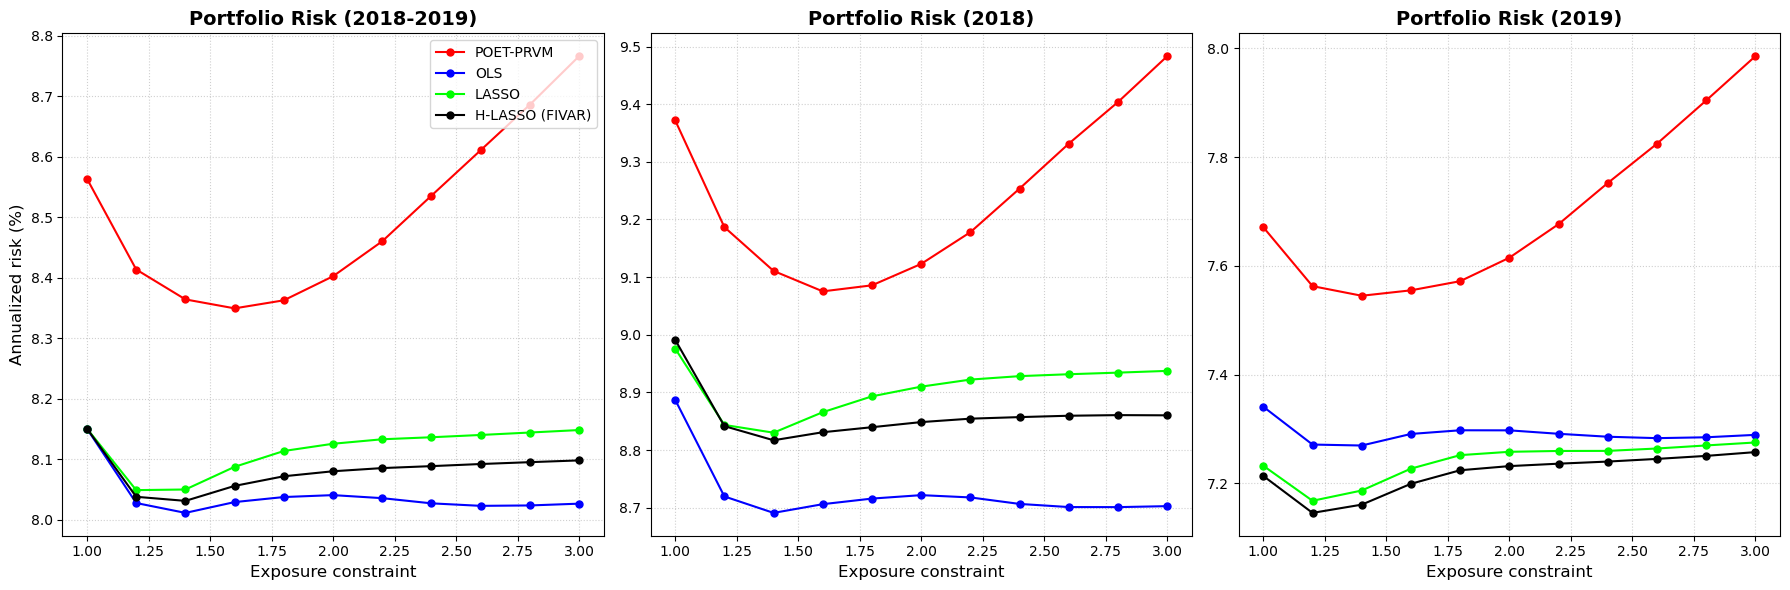

In [28]:
## 실행

# 평가 기간 설정
start_eval = '2018-01-01'
end_eval = '2019-12-31'

# 데이터 변환 실행
pred_cov_sets, returns_input, eval_dates = align_data_for_correct_code(
    df_final, jv_dict, ret_10min_df, start_eval, end_eval
)

# 리스크 계산 실행
c0_values = np.linspace(1.0, 3.0, 11)
results_risk = {}

print("\n>>> Running Portfolio Optimization...")
for model_name, pred_cov in pred_cov_sets.items():
    print(f"Processing {model_name}...")
    # 정답 코드의 함수 사용 (evaluate_risks_by_c0)
    risks = evaluate_risks_by_c0(pred_cov, returns_input, c0_values, n_jobs=6)
    results_risk[model_name] = risks # (len(c0), T)

## 시각화
# 기간 분리
T = len(eval_dates)
mid_point = T // 2

# 연율화 계수 (하루 39개 10분 데이터 기준이 아니라, 일별 realized variance 합이므로 252만 곱함)
# compute_portfolio_risk 결과는 sum(r^2)인 일별 RV임.
# 따라서 연율화 변동성(%) = sqrt(mean(RV) * 252) * 100
one_year = 252

risk_sets_plot = []
# 2018-2018
risk_p1 = []
for m in ["POET-PRVM", "OLS", "LASSO", "H-LASSO (FIVAR)"]:
    r_mean = np.mean(results_risk[m], axis=1) # c0별 평균 RV
    risk_ann = np.sqrt(r_mean * one_year) * 100
    risk_p1.append(risk_ann)

# 2018
risk_p2 = []
for m in ["POET-PRVM", "OLS", "LASSO", "H-LASSO (FIVAR)"]:
    r_mean = np.mean(results_risk[m][:, :mid_point], axis=1)
    risk_ann = np.sqrt(r_mean * one_year) * 100
    risk_p2.append(risk_ann)

# 2019
risk_p3 = []
for m in ["POET-PRVM", "OLS", "LASSO", "H-LASSO (FIVAR)"]:
    r_mean = np.mean(results_risk[m][:, mid_point:], axis=1)
    risk_ann = np.sqrt(r_mean * one_year) * 100
    risk_p3.append(risk_ann)

risk_sets = [tuple(risk_p1), tuple(risk_p2), tuple(risk_p3)]
labels = ["POET-PRVM", "OLS", "LASSO", "H-LASSO (FIVAR)"]
colors = ['red', 'blue', 'lime', 'black']

plt_risk_plots(c0_values, risk_sets, labels, colors=colors)

# TEST (FIVAR)